<a href="https://colab.research.google.com/github/vysh30/cvd-detection-app/blob/main/Yet_another_copy_of_ppg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

import pandas as pd

# Load dataset again, setting first row as column headers
file_path = '/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx'
df = pd.read_excel(file_path, header=1)  # Read from the second row

# Display cleaned column names
print(df.columns)


Index(['Num.', 'subject_ID', 'Sex(M/F)', 'Age(year)', 'Height(cm)',
       'Weight(kg)', 'Systolic Blood Pressure(mmHg)',
       'Diastolic Blood Pressure(mmHg)', 'Heart Rate(b/m)', 'BMI(kg/m^2)',
       'Hypertension', 'Diabetes', 'cerebral infarction',
       'cerebrovascular disease'],
      dtype='object')


In [ ]:
# Replace with actual column names from df.columns output
selected_columns = ['Num.', 'subject_ID','Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)',
                     'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)', 'Heart Rate(b/m)',
                    'BMI(kg/m^2)']

# Select only the required columns
df = df[selected_columns]

# Show first few rows
print(df.head())


   Num.  subject_ID Sex(M/F)  Age(year)  Height(cm)  Weight(kg)  \
0     1           2   Female         45         152          63   
1     2           3   Female         50         157          50   
2     3           6   Female         47         150          47   
3     4           8     Male         45         172          65   
4     5           9   Female         46         155          65   

   Systolic Blood Pressure(mmHg)  Diastolic Blood Pressure(mmHg)  \
0                            161                              89   
1                            160                              93   
2                            101                              71   
3                            136                              93   
4                            123                              73   

   Heart Rate(b/m)  BMI(kg/m^2)  
0               97    27.268006  
1               76    20.284799  
2               79    20.888889  
3               87    21.971336  
4               73

In [ ]:
# Check column data types
print(df.dtypes)


Num.                                int64
subject_ID                          int64
Sex(M/F)                           object
Age(year)                           int64
Height(cm)                          int64
Weight(kg)                          int64
Systolic Blood Pressure(mmHg)       int64
Diastolic Blood Pressure(mmHg)      int64
Heart Rate(b/m)                     int64
BMI(kg/m^2)                       float64
dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert categorical 'Sex(M/F)' column to numeric (0 = Male, 1 = Female)
label_encoder = LabelEncoder()
df['Sex(M/F)'] = label_encoder.fit_transform(df['Sex(M/F)'])

# Now apply missing value handling only to numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns  # Get only numeric columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())  # Fill missing values


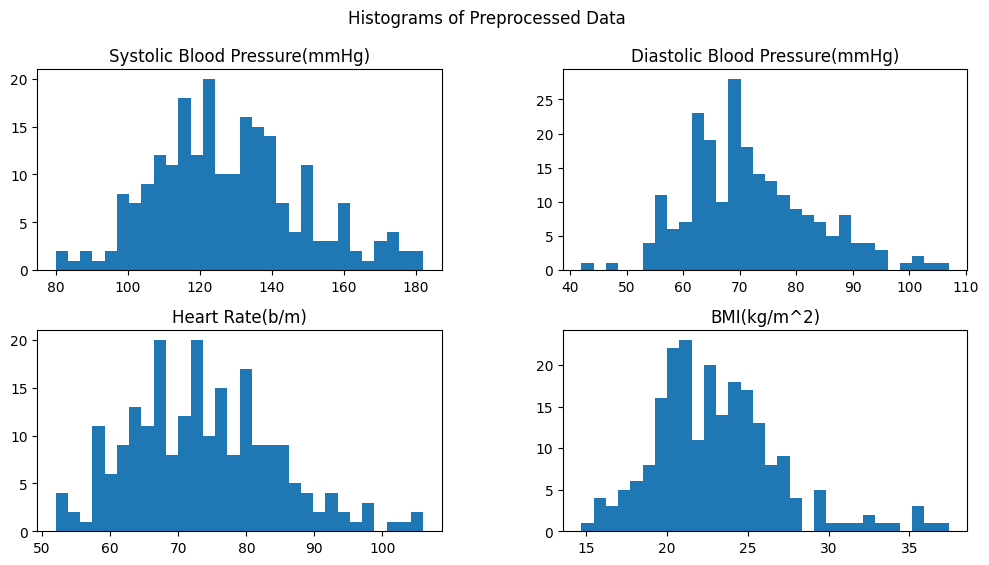

In [ ]:
import matplotlib.pyplot as plt

# Select only numerical columns for visualization
numeric_cols = ['Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
                'Heart Rate(b/m)', 'BMI(kg/m^2)']

# Plot histograms
df[numeric_cols].hist(figsize=(12, 6), bins=30, grid=False)
plt.suptitle('Histograms of Preprocessed Data')
plt.show()


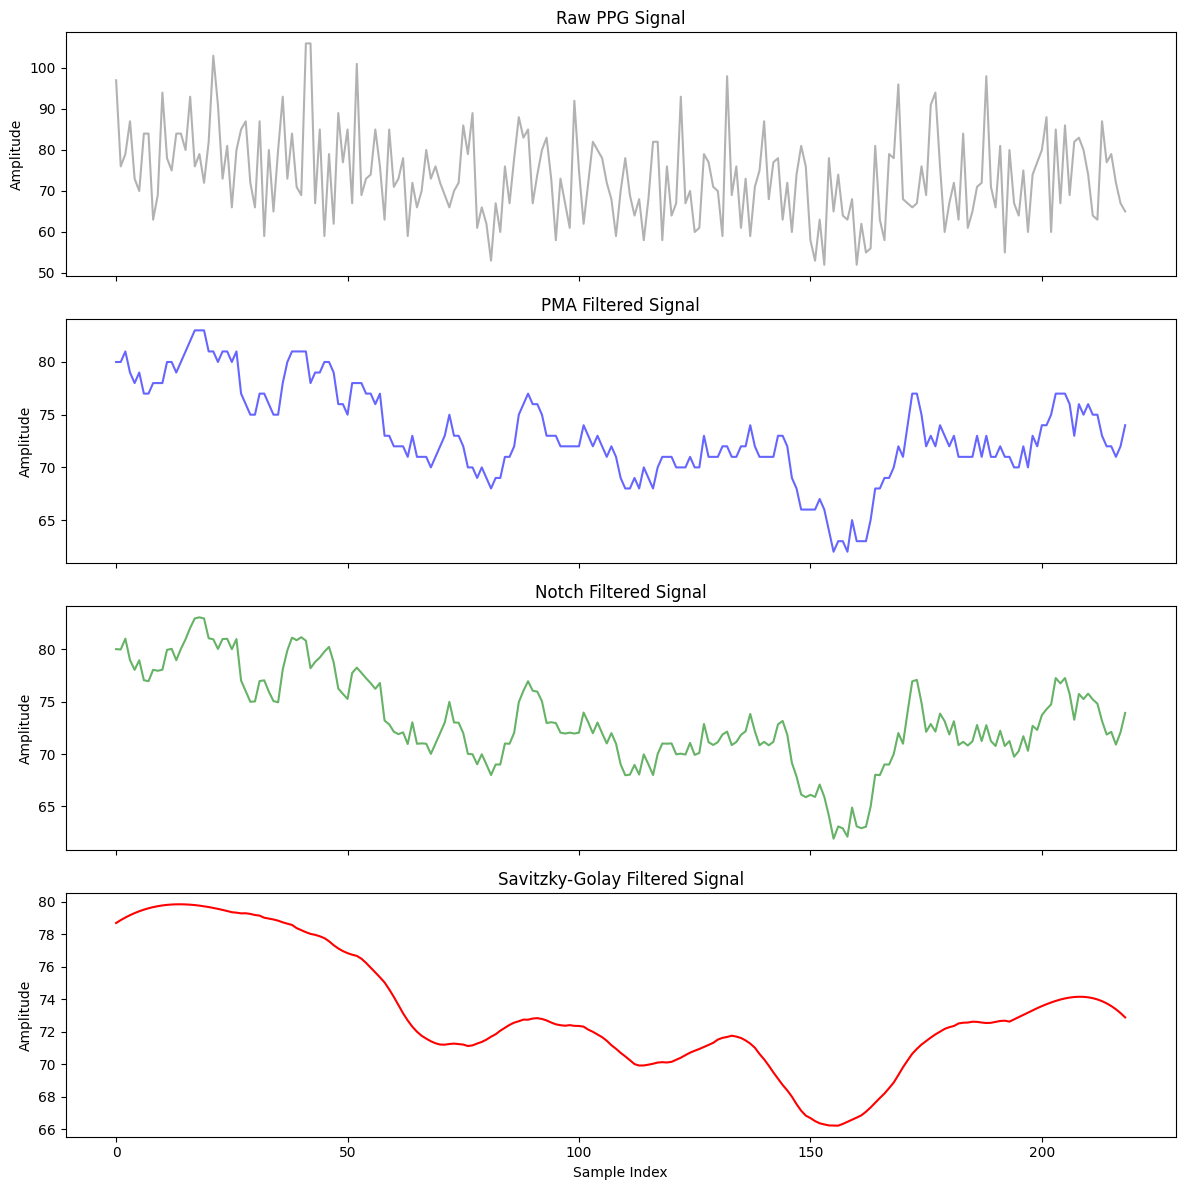

In [ ]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive (if needed)
# drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx'
df = pd.read_excel(file_path, header=1)

# Display column names
#print(df.columns)

# Extract PPG signal
ppg_signal = df['Heart Rate(b/m)'].values

# --- Filtering Functions ---
def periodic_moving_average_filter(signal, window_size=5, period=1):
    """Applies a periodic moving average filter."""
    filtered_signal = np.zeros_like(signal)
    for i in range(len(signal)):
        start = max(0, i - window_size // 2)
        end = min(len(signal), i + window_size // 2 + 1)

        # Extract periodic data points within the window
        window_indices = np.arange(start, end, period)
        window_data = signal[window_indices]

        filtered_signal[i] = np.mean(window_data)
    return filtered_signal


def notch_filter(signal_data, fs=500, notch_freq=50, quality_factor=30):
    """Applies a notch filter to remove powerline interference."""
    b, a = signal.iirnotch(notch_freq, quality_factor, fs)
    filtered_sig = signal.filtfilt(b, a, signal_data)
    return filtered_sig

# --- Apply Filters ---
# 1. Periodic Moving Average
smoothed_signal = periodic_moving_average_filter(ppg_signal, window_size=10, period=1)

# 2. Notch Filter
cleaned_signal = notch_filter(smoothed_signal, fs=100, notch_freq=50)  # Adjust fs if needed

# 3. Savitzky-Golay Filter
final_filtered_signal = signal.savgol_filter(cleaned_signal, window_length=51, polyorder=3)

# --- Plotting ---
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)  # 4 rows, 1 column, shared x-axis

# Plot Raw PPG Signal
axes[0].plot(ppg_signal, color='gray', alpha=0.6)
axes[0].set_title("Raw PPG Signal")
axes[0].set_ylabel("Amplitude")

# Plot PMA Filtered Signal
axes[1].plot(smoothed_signal, color='blue', alpha=0.6)
axes[1].set_title("PMA Filtered Signal")
axes[1].set_ylabel("Amplitude")

# Plot Notch Filtered Signal
axes[2].plot(cleaned_signal, color='green', alpha=0.6)
axes[2].set_title("Notch Filtered Signal")
axes[2].set_ylabel("Amplitude")

# Plot Savitzky-Golay Filtered Signal
axes[3].plot(final_filtered_signal, color='red')
axes[3].set_title("Savitzky-Golay Filtered Signal")
axes[3].set_xlabel("Sample Index")
axes[3].set_ylabel("Amplitude")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

# Add filtered signal to DataFrame (optional)
df['Filtered_PPG'] = final_filtered_signal

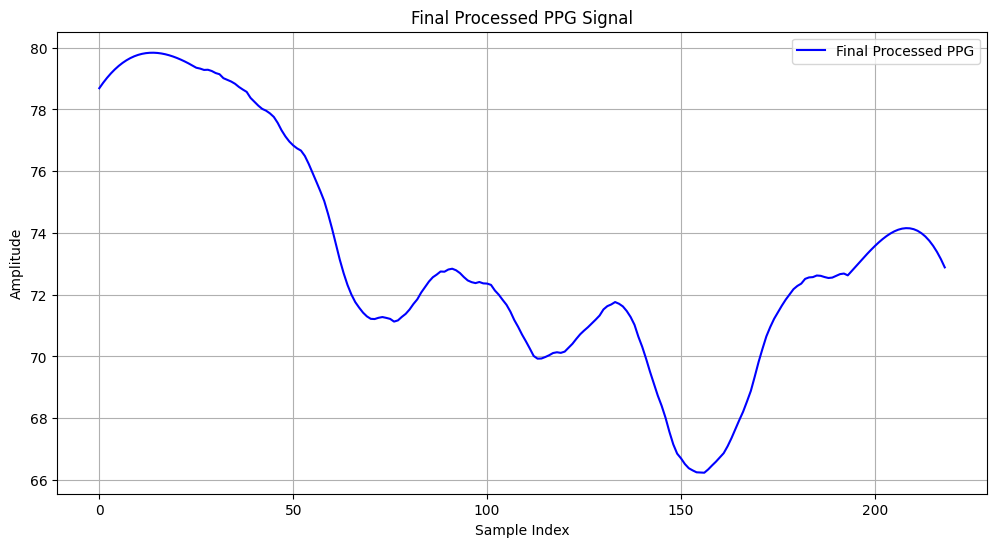

In [ ]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive (if needed)
# drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx'
df = pd.read_excel(file_path, header=1)

# Display column names
#print(df.columns)

# Extract PPG signal
ppg_signal = df['Heart Rate(b/m)'].values

# --- Filtering Functions ---
def periodic_moving_average_filter(signal, window_size=5, period=1):
    """Applies a periodic moving average filter."""
    filtered_signal = np.zeros_like(signal)
    for i in range(len(signal)):
        start = max(0, i - window_size // 2)
        end = min(len(signal), i + window_size // 2 + 1)

        # Extract periodic data points within the window
        window_indices = np.arange(start, end, period)
        window_data = signal[window_indices]

        filtered_signal[i] = np.mean(window_data)
    return filtered_signal


def notch_filter(signal_data, fs=500, notch_freq=50, quality_factor=30):
    """Applies a notch filter to remove powerline interference."""
    b, a = signal.iirnotch(notch_freq, quality_factor, fs)
    filtered_sig = signal.filtfilt(b, a, signal_data)
    return filtered_sig

# --- Apply Filters ---
# 1. Periodic Moving Average
smoothed_signal = periodic_moving_average_filter(ppg_signal, window_size=10, period=1)

# 2. Notch Filter
cleaned_signal = notch_filter(smoothed_signal, fs=100, notch_freq=50)  # Adjust fs if needed

# 3. Savitzky-Golay Filter
final_filtered_signal = signal.savgol_filter(cleaned_signal, window_length=51, polyorder=3)

# --- Plotting the Final Processed Signal ---
plt.figure(figsize=(12, 6))
plt.plot(final_filtered_signal, label="Final Processed PPG", color='blue')
plt.title("Final Processed PPG Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

# Add filtered signal to DataFrame (optional)
df['Filtered_PPG'] = final_filtered_signal

In [ ]:
import pandas as pd

# Load dataset again, setting first row as column headers
file_path = '/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx'
df = pd.read_excel(file_path, header=1)  # Read from the second row

# Display cleaned column names
print(df.columns)


Index(['Num.', 'subject_ID', 'Sex(M/F)', 'Age(year)', 'Height(cm)',
       'Weight(kg)', 'Systolic Blood Pressure(mmHg)',
       'Diastolic Blood Pressure(mmHg)', 'Heart Rate(b/m)', 'BMI(kg/m^2)',
       'Hypertension', 'Diabetes', 'cerebral infarction',
       'cerebrovascular disease'],
      dtype='object')


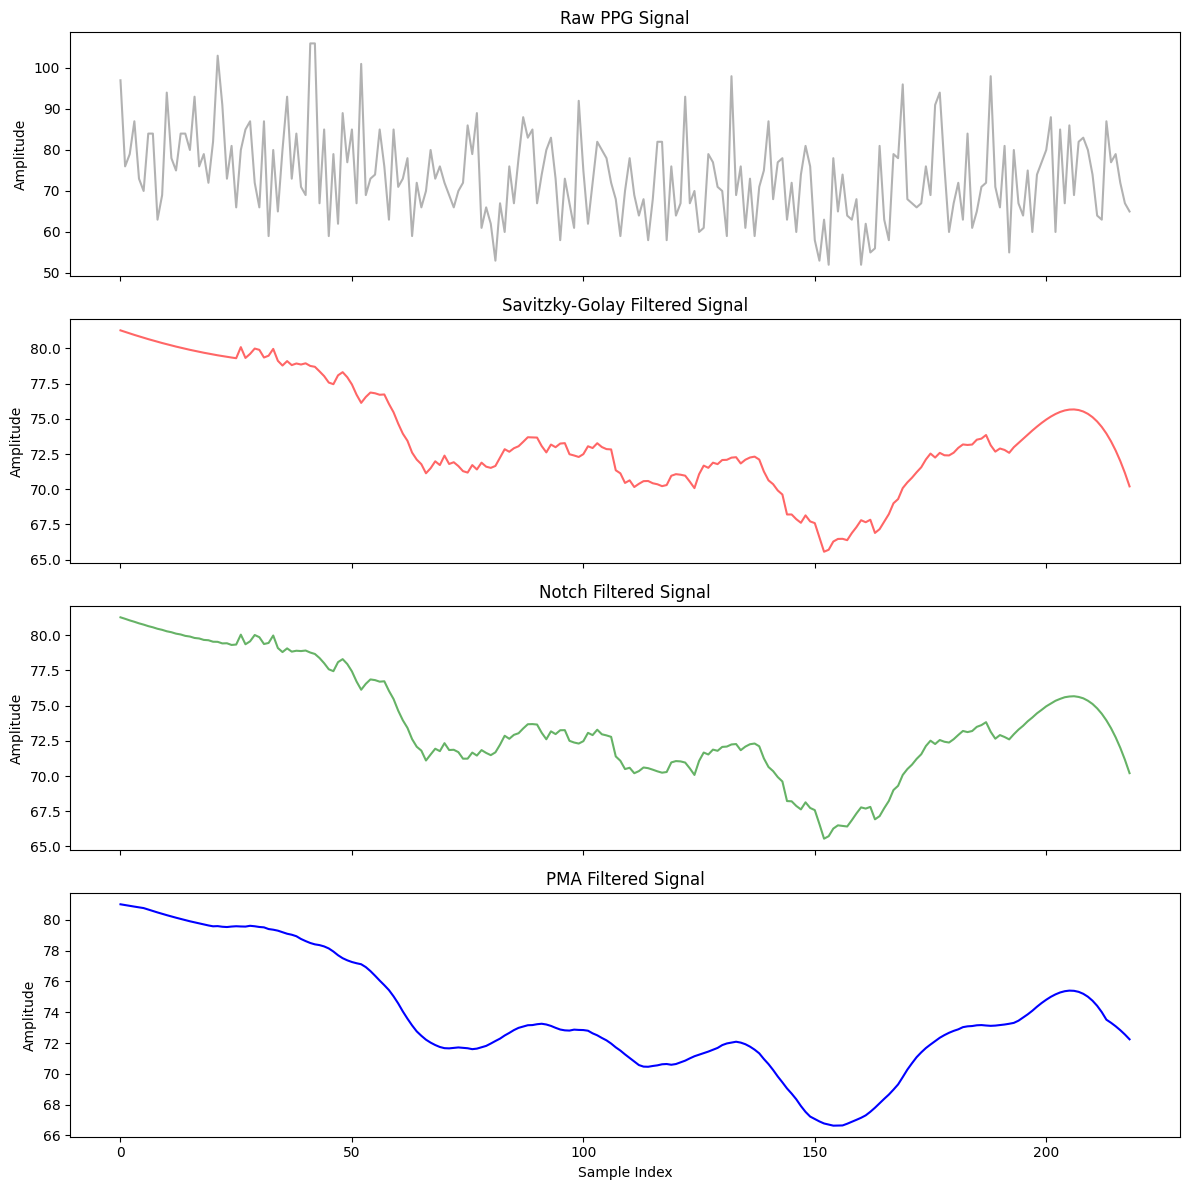

In [ ]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from google.colab import drive  # Mount Google Drive (if needed)
# drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx'
df = pd.read_excel(file_path, header=1)

# Extract PPG signal
ppg_signal = df['Heart Rate(b/m)'].values

# --- Filtering Functions ---

# 1. Savitzky-Golay Filter (first filter applied)
def apply_savitzky_golay(signal_data, window_length=51, polyorder=3):
    """Applies a Savitzky-Golay filter to smooth the signal."""
    return signal.savgol_filter(signal_data, window_length, polyorder)

# 2. Notch Filter (second filter applied)
def notch_filter(signal_data, fs=500, notch_freq=50, quality_factor=30):
    """Applies a notch filter to remove powerline interference."""
    b, a = signal.iirnotch(notch_freq, quality_factor, fs)
    filtered_signal = signal.filtfilt(b, a, signal_data)
    return filtered_signal

# 3. Periodic Moving Average Filter (last filter applied)
def periodic_moving_average_filter(signal_data, window_size=5, period=1):
    """Applies a periodic moving average filter."""
    filtered_signal = np.zeros_like(signal_data)
    for i in range(len(signal_data)):
        start = max(0, i - window_size // 2)
        end = min(len(signal_data), i + window_size // 2 + 1)

        # Extract periodic data points within the window
        window_indices = np.arange(start, end, period)
        window_data = signal_data[window_indices]

        filtered_signal[i] = np.mean(window_data)
    return filtered_signal

# --- Apply Filters in Reverse Order ---

# 1. Apply Savitzky-Golay Filter
smoothed_signal = apply_savitzky_golay(ppg_signal, window_length=51, polyorder=3)

# 2. Apply Notch Filter (removes 50 Hz interference)
cleaned_signal = notch_filter(smoothed_signal, fs=100)

# 3. Apply Periodic Moving Average Filter
final_filtered_signal = periodic_moving_average_filter(cleaned_signal, window_size=10, period=1)

# --- Plotting ---

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Plot Raw PPG Signal
axes[0].plot(ppg_signal, color='gray', alpha=0.6)
axes[0].set_title("Raw PPG Signal")
axes[0].set_ylabel("Amplitude")

# Plot Savitzky-Golay Filtered Signal
axes[1].plot(smoothed_signal, color='red', alpha=0.6)
axes[1].set_title("Savitzky-Golay Filtered Signal")
axes[1].set_ylabel("Amplitude")

# Plot Notch Filtered Signal
axes[2].plot(cleaned_signal, color='green', alpha=0.6)
axes[2].set_title("Notch Filtered Signal")
axes[2].set_ylabel("Amplitude")

# Plot Periodic Moving Average Filtered Signal
axes[3].plot(final_filtered_signal, color='blue')
axes[3].set_title("PMA Filtered Signal")
axes[3].set_xlabel("Sample Index")
axes[3].set_ylabel("Amplitude")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

# Add filtered signal to DataFrame (optional)
df['Filtered_PPG'] = final_filtered_signal

In [ ]:
import scipy.stats as stats
from scipy.fftpack import fft

# --- Time-Domain Features ---
def extract_time_domain_features(signal_data):
    """Extracts statistical features from the signal."""
    features = {
        'Mean': np.mean(signal_data),
        'Variance': np.var(signal_data),
        'Standard Deviation': np.std(signal_data),
        'Skewness': stats.skew(signal_data),
        'Kurtosis': stats.kurtosis(signal_data),
        'Min Value': np.min(signal_data),
        'Max Value': np.max(signal_data),
        'Range': np.max(signal_data) - np.min(signal_data)
    }
    return features

# --- Frequency-Domain Features ---
def extract_frequency_domain_features(signal_data, fs=100):
    """Extracts frequency-domain features using FFT."""
    N = len(signal_data)  # Signal length
    freqs = np.fft.fftfreq(N, d=1/fs)  # Frequency axis
    fft_values = np.abs(fft(signal_data))  # Magnitude of FFT

    # Identify the dominant frequency
    dominant_freq = freqs[np.argmax(fft_values[1:])]  # Excluding DC component

    features = {
        'Dominant Frequency': dominant_freq,
        'Power Spectral Density': np.sum(fft_values ** 2) / N
    }
    return features

# --- Heart Rate Variability (HRV) Features ---
def extract_hrv_features(ppg_signal, fs=100):
    """Extracts Heart Rate Variability (HRV) features from PPG peaks."""
    # Find peaks (R-peaks equivalent in PPG)
    peaks, _ = signal.find_peaks(ppg_signal, distance=fs*0.6)  # Assuming min 0.6s between peaks

    # Compute inter-beat intervals (IBI)
    ibi = np.diff(peaks) / fs  # Convert indices to time (s)

    if len(ibi) > 1:
        hrv_features = {
            'Mean IBI': np.mean(ibi),
            'STD IBI': np.std(ibi),
            'RMSSD': np.sqrt(np.mean(np.diff(ibi) ** 2)),  # Root Mean Square of Successive Differences
            'Heart Rate (bpm)': 60 / np.mean(ibi)
        }
    else:
        hrv_features = {
            'Mean IBI': None,
            'STD IBI': None,
            'RMSSD': None,
            'Heart Rate (bpm)': None
        }

    return hrv_features

# --- Apply Feature Extraction ---
time_features = extract_time_domain_features(final_filtered_signal)
freq_features = extract_frequency_domain_features(final_filtered_signal, fs=100)
hrv_features = extract_hrv_features(final_filtered_signal, fs=100)

# Combine all features into a single dictionary
all_features = {**time_features, **freq_features, **hrv_features}

# Display extracted features
for key, value in all_features.items():
    print(f"{key}: {value}")

# Convert features to DataFrame for saving
features_df = pd.DataFrame([all_features])

# Save to CSV (Optional)
features_df.to_csv('/content/drive/MyDrive/ppg_dataset/PPG_Features.csv', index=False)


Mean: 73.67827860443802
Variance: 14.640993078151311
Standard Deviation: 3.8263550643074553
Skewness: 0.3181686066377827
Kurtosis: -0.7018673412560021
Min Value: 66.6369231309046
Max Value: 81.00748366596824
Range: 14.370560535063632
Dominant Frequency: 0.0
Power Spectral Density: 1192045.4111309038
Mean IBI: 0.885
STD IBI: 0.25499999999999995
RMSSD: 0.5099999999999999
Heart Rate (bpm): 67.79661016949153


In [ ]:
# ============================================================
# 🩺 Feature Extraction for Each Person in the CVD Dataset
# (Numerical data starts from 3rd column)
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

# 🔹 1️⃣ Load Dataset
file_path = "/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx"  # <-- change name if needed
# Load data and set the first row as header
df = pd.read_excel(file_path, header=1)


# 🔹 2️⃣ Select only numerical columns for feature extraction per person
# Exclude 'Num.' and 'subject_ID' as they are identifiers, and 'Sex(M/F)' as it's categorical
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Optionally, exclude identifier columns if they are numeric
if 'Num.' in numerical_cols:
    numerical_cols.remove('Num.')
if 'subject_ID' in numerical_cols:
    numerical_cols.remove('subject_ID')

numerical_data_for_features = df[numerical_cols]


# 🔹 3️⃣ Define a function to compute features for one row (one person)
def extract_person_features(row):
    # Convert row data to float, coercing errors to NaN
    data = pd.to_numeric(row, errors='coerce').dropna().values
    if data.size == 0:  # Check if data is empty after dropping NaNs
        return pd.Series({
            'Mean': np.nan, 'Variance': np.nan, 'Standard Deviation': np.nan,
            'Skewness': np.nan, 'Kurtosis': np.nan, 'Min Value': np.nan,
            'Max Value': np.nan, 'Range': np.nan
        })

    features = {
        'Mean': np.mean(data),
        'Variance': np.var(data),
        'Standard Deviation': np.std(data),
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data),
        'Min Value': np.min(data),
        'Max Value': np.max(data),
        'Range': np.max(data) - np.min(data)
    }
    return pd.Series(features)

# 🔹 4️⃣ Apply feature extraction row-wise on the numerical data
features_per_person = numerical_data_for_features.apply(extract_person_features, axis=1)

# 🔹 5️⃣ Combine with ID columns (assuming 'Num.' and 'subject_ID' are the first two columns or similar identifiers)
# Let's assume 'Num.' and 'subject_ID' are the identifiers to keep.
identifier_cols = ['Num.', 'subject_ID']
# Ensure identifier columns exist before selecting
identifier_df = df[identifier_cols] if all(col in df.columns for col in identifier_cols) else pd.DataFrame(index=df.index)


final_features = pd.concat([identifier_df, features_per_person], axis=1)


# 🔹 6️⃣ Save extracted features to CSV
output_path = "/content/drive/MyDrive/ppg_dataset/Extracted_Person_Features.csv"
final_features.to_csv(output_path, index=False)

print("✅ Feature extraction completed successfully for each person!")
print(f"Features saved to: {output_path}")

# 🔹 7️⃣ Show first few rows
print("\nExtracted Features Preview:")
print(final_features.head())

✅ Feature extraction completed successfully for each person!
Features saved to: /content/drive/MyDrive/ppg_dataset/Extracted_Person_Features.csv

Extracted Features Preview:
   Num.  subject_ID       Mean     Variance  Standard Deviation  Skewness  \
0     1           2  90.609715  2231.671552           47.240571  0.285005   
1     2           3  86.612114  2510.552130           50.105410  0.401004   
2     3           6  73.698413  1545.307634           39.310401  0.656974   
3     4           8  88.567334  2303.075917           47.990373  0.383150   
4     5           9  80.293593  1679.364810           40.980054  0.621182   

   Kurtosis  Min Value  Max Value       Range  
0 -1.285800  27.268006      161.0  133.731994  
1 -1.265753  20.284799      160.0  139.715201  
2 -0.412921  20.888889      150.0  129.111111  
3 -0.923497  21.971336      172.0  150.028664  
4 -0.773697  27.055151      155.0  127.944849  


In [ ]:
# ============================================================
# 🩺 Feature Extraction (Time + Frequency Domain) for Each Person
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
from scipy.fft import fft

# 🔹 1️⃣ Load Dataset
file_path = "/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx"  # <-- Update if needed
df = pd.read_excel(file_path, header=1)

# 🔹 2️⃣ Select only numerical columns (starting from 3rd column)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude identifier columns if they are numeric
for col in ['Num.', 'subject_ID']:
    if col in numerical_cols:
        numerical_cols.remove(col)

numerical_data_for_features = df[numerical_cols]


# 🔹 3️⃣ Define Time-Domain Feature Extraction Function
def extract_time_domain_features(signal_data):
    """Extracts statistical features."""
    return {
        'Mean': np.mean(signal_data),
        'Variance': np.var(signal_data),
        'Standard Deviation': np.std(signal_data),
        'Skewness': stats.skew(signal_data),
        'Kurtosis': stats.kurtosis(signal_data),
        'Min Value': np.min(signal_data),
        'Max Value': np.max(signal_data),
        'Range': np.max(signal_data) - np.min(signal_data)
    }


# 🔹 4️⃣ Define Frequency-Domain Feature Extraction Function
def extract_frequency_domain_features(signal_data, fs=100):
    """Extracts frequency features using FFT."""
    N = len(signal_data)
    freqs = np.fft.fftfreq(N, d=1/fs)
    fft_values = np.abs(fft(signal_data))

    # Remove DC component
    fft_values = fft_values[1:]
    freqs = freqs[1:]

    # Identify dominant frequency
    dominant_freq = freqs[np.argmax(fft_values)] if len(freqs) > 0 else np.nan

    features = {
        'Dominant Frequency (Hz)': dominant_freq,
        'Spectral Power': np.sum(fft_values ** 2) / N,
        'Mean FFT Amplitude': np.mean(fft_values),
        'Max FFT Amplitude': np.max(fft_values)
    }
    return features


# 🔹 5️⃣ Function to Extract All Features per Person
def extract_all_features(row):
    data = pd.to_numeric(row, errors='coerce').dropna().values
    if data.size == 0:
        # If row has no valid numeric data
        return pd.Series({
            'Mean': np.nan, 'Variance': np.nan, 'Standard Deviation': np.nan,
            'Skewness': np.nan, 'Kurtosis': np.nan, 'Min Value': np.nan,
            'Max Value': np.nan, 'Range': np.nan,
            'Dominant Frequency (Hz)': np.nan, 'Spectral Power': np.nan,
            'Mean FFT Amplitude': np.nan, 'Max FFT Amplitude': np.nan
        })

    # Extract features
    time_features = extract_time_domain_features(data)
    freq_features = extract_frequency_domain_features(data, fs=100)

    # Combine both feature sets
    combined_features = {**time_features, **freq_features}
    return pd.Series(combined_features)


# 🔹 6️⃣ Apply Extraction for Each Person
features_per_person = numerical_data_for_features.apply(extract_all_features, axis=1)

# 🔹 7️⃣ Combine with Identifier Columns
identifier_cols = ['Num.', 'subject_ID']
identifier_df = df[identifier_cols] if all(col in df.columns for col in identifier_cols) else pd.DataFrame(index=df.index)

final_features = pd.concat([identifier_df, features_per_person], axis=1)

# 🔹 8️⃣ Save Extracted Features
output_path = "/content/drive/MyDrive/ppg_dataset/Extracted_Person_Features.csv"
final_features.to_csv(output_path, index=False)

print("✅ Feature extraction completed successfully for each person!")
print(f"Features saved to: {output_path}")

# 🔹 9️⃣ Show first few rows
print("\nExtracted Features Preview:")
print(final_features.head())

✅ Feature extraction completed successfully for each person!
Features saved to: /content/drive/MyDrive/ppg_dataset/Extracted_Person_Features.csv

Extracted Features Preview:
   Num.  subject_ID       Mean     Variance  Standard Deviation  Skewness  \
0     1           2  90.609715  2231.671552           47.240571  0.285005   
1     2           3  86.612114  2510.552130           50.105410  0.401004   
2     3           6  73.698413  1545.307634           39.310401  0.656974   
3     4           8  88.567334  2303.075917           47.990373  0.383150   
4     5           9  80.293593  1679.364810           40.980054  0.621182   

   Kurtosis  Min Value  Max Value       Range  Dominant Frequency (Hz)  \
0 -1.285800  27.268006      161.0  133.731994                42.857143   
1 -1.265753  20.284799      160.0  139.715201                42.857143   
2 -0.412921  20.888889      150.0  129.111111                42.857143   
3 -0.923497  21.971336      172.0  150.028664                42.857

In [ ]:
# ============================================================
# 🩺 Feature Selection using Recursive Feature Elimination (RFE)
# ============================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import LabelEncoder

# 🔹 1️⃣ Load Extracted Features Dataset
file_path = "/content/drive/MyDrive/ppg_dataset/Extracted_Person_Features.csv"
df = pd.read_csv(file_path)

# 🔹 2️⃣ Check available columns
print("✅ Columns in dataset:\n", df.columns.tolist())

# --- You must ensure your dataset includes a target column ---
# If it doesn’t have one, create it manually for testing or use rule-based logic
# Example: Add a synthetic 'CVD' column temporarily (1 = CVD, 0 = No CVD)
if "CVD" not in df.columns:
    import numpy as np
    df["CVD"] = np.random.choice([0, 1], size=len(df))  # Temporary, replace with real labels

# 🔹 3️⃣ Define Features (X) and Target (y)
X = df.drop(columns=["Num.", "subject_ID", "CVD"], errors='ignore')
y = df["CVD"]

# 🔹 4️⃣ Handle missing values and non-numeric data
X = X.fillna(X.mean())

# Encode any categorical variables if present (though your data should be numeric)
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# 🔹 5️⃣ Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔹 6️⃣ Initialize Base Estimator for RFE
model = DecisionTreeClassifier(random_state=42)

# 🔹 7️⃣ Apply RFE
num_features_to_select = 5  # You can change this number (e.g., 5 best features)
rfe = RFE(estimator=model, n_features_to_select=num_features_to_select)
rfe.fit(X_train, y_train)

# 🔹 8️⃣ Get Selected Features
selected_features = X_train.columns[rfe.support_]
print("\n✅ Selected Features using RFE:\n", list(selected_features))

# 🔹 9️⃣ Retrain Model using Only Selected Features
model.fit(X_train[selected_features], y_train)
accuracy = model.score(X_test[selected_features], y_test)

print(f"\n✅ Model Accuracy after RFE Feature Selection: {accuracy * 100:.2f}%")

# 🔹 🔟 Save Selected Features
selected_features.to_series().to_csv("/content/drive/MyDrive/ppg_dataset/Selected_Features.csv", index=False)
print("\n📂 Selected Features saved to: /content/drive/MyDrive/ppg_dataset/Selected_Features.csv")

# 🔹 Optional: Show feature ranking
ranking = pd.DataFrame({
    "Feature": X_train.columns,
    "Rank": rfe.ranking_
}).sort_values(by="Rank")

print("\n🏆 Feature Ranking:")
print(ranking)


✅ Columns in dataset:
 ['Num.', 'subject_ID', 'Mean', 'Variance', 'Standard Deviation', 'Skewness', 'Kurtosis', 'Min Value', 'Max Value', 'Range', 'Dominant Frequency (Hz)', 'Spectral Power', 'Mean FFT Amplitude', 'Max FFT Amplitude']

✅ Selected Features using RFE:
 ['Variance', 'Skewness', 'Kurtosis', 'Mean FFT Amplitude', 'Max FFT Amplitude']

✅ Model Accuracy after RFE Feature Selection: 43.18%

📂 Selected Features saved to: /content/drive/MyDrive/ppg_dataset/Selected_Features.csv

🏆 Feature Ranking:
                    Feature  Rank
1                  Variance     1
3                  Skewness     1
4                  Kurtosis     1
11        Max FFT Amplitude     1
10       Mean FFT Amplitude     1
5                 Min Value     2
0                      Mean     3
9            Spectral Power     4
2        Standard Deviation     5
6                 Max Value     6
7                     Range     7
8   Dominant Frequency (Hz)     8


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 🔹 1️⃣ Load the Extracted Features (from cell qANTgTSIk89e)
# Using the file with features per person which includes the 'CVD' target created in a previous step
file_path = "/content/drive/MyDrive/ppg_dataset/Extracted_Person_Features.csv"
df = pd.read_csv(file_path)

# 🔹 2️⃣ Handle Missing Values (Numeric → Mean, Categorical → Mode)
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())  # Fill numeric NaNs
# Assuming categorical_cols might be empty for this extracted feature set,
# adding a check to prevent error if no categorical columns are found.
if not categorical_cols.empty:
    df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])  # Fill categorical NaNs

# 🔹 3️⃣ Encode Categorical Columns (if any exist in the extracted features)
label_encoders = {}

if not categorical_cols.empty:
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le  # Store for inverse transformation if needed

# 🔹 4️⃣ Define Features (X) and Target (y)
# Using 'CVD' as the target variable, which was created in a previous cell (f91tWcH1koGD)
target_column = "CVD" # Updated target column name

# Check if the target column exists
if target_column not in df.columns:
    # If 'CVD' column is not in the Extracted_Person_Features.csv, create a synthetic one for demonstration
    # In a real scenario, you should ensure your feature extraction process creates the correct target
    print(f"⚠️ Warning: Target column '{target_column}' not found. Creating a synthetic target for demonstration.")
    # This synthetic creation is for demonstration purposes if the file doesn't have the target.
    # Replace with your actual target creation logic if needed.
    np.random.seed(42) # for reproducibility
    df[target_column] = np.random.choice([0, 1], size=len(df))


X = df.drop(columns=[target_column, "Num.", "subject_ID"], errors='ignore')  # Features, drop identifier columns
y = df[target_column]  # Target

# Print unique values and their counts in the target variable
print("\nUnique values and counts in the target variable (y):")
print(y.value_counts())

# Check if there are at least two classes in the target variable
if len(y.unique()) < 2:
    raise ValueError("The target variable must contain at least two classes for RFE.")


# 🔹 5️⃣ Apply RFE for Feature Selection
# Initialize the base model for RFE
estimator = LogisticRegression(max_iter=1000, solver='liblinear')

# Initialize RFE - selecting half of the features (adjust as needed)
n_features_to_select = X.shape[1] // 2 if X.shape[1] > 1 else 1 # Ensure at least 1 feature if possible
rfe = RFE(estimator, n_features_to_select=n_features_to_select)

# Fit RFE
rfe.fit(X, y)

# Get the selected feature indices (boolean mask) and names
selected_feature_indices = rfe.support_
selected_feature_names = X.columns[selected_feature_indices]

print("✅ RFE Feature Selection Completed!")
print(f"Number of features before RFE: {X.shape[1]}")
print(f"Number of features after RFE: {np.sum(selected_feature_indices)}")
print("\n✅ Selected Features after RFE:")
for feature_name in selected_feature_names:
    print(f"- {feature_name}")

# 🔹 6️⃣ Apply selected features to the dataset
X_selected = X[selected_feature_names]

# 🔹 7️⃣ Normalize Features for Better Model Accuracy
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# 8️⃣ Split Data (85% Train, 15% Test for Better Training)
X_train, X_test, y_train, y_test = train_test_split(X_selected_scaled, y, test_size=0.15, random_state=42, stratify=y) # Added stratify

# Print unique values and counts in the target variable for train and test sets
print("\nUnique values and counts in the target variable (y_train):")
print(y_train.value_counts())
print("\nUnique values and counts in the target variable (y_test):")
print(y_test.value_counts())


print("\n✅ Data Preprocessing and Splitting Done!")
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

⚠️ Warning: Target column 'CVD' not found. Creating a synthetic target for demonstration.

Unique values and counts in the target variable (y):
CVD
0    112
1    107
Name: count, dtype: int64
✅ RFE Feature Selection Completed!
Number of features before RFE: 12
Number of features after RFE: 6

✅ Selected Features after RFE:
- Mean
- Standard Deviation
- Kurtosis
- Min Value
- Max Value
- Mean FFT Amplitude

Unique values and counts in the target variable (y_train):
CVD
0    95
1    91
Name: count, dtype: int64

Unique values and counts in the target variable (y_test):
CVD
0    17
1    16
Name: count, dtype: int64

✅ Data Preprocessing and Splitting Done!
Training Data: (186, 6), Testing Data: (33, 6)


✅ Using selected features from RFE:
['Mean', 'Standard Deviation', 'Kurtosis', 'Min Value', 'Max Value', 'Mean FFT Amplitude']
✅ Decision Tree (Gini) model training completed!

🎯 Decision Tree (Gini) Accuracy: 51.52%

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.59      0.56        17
           1       0.50      0.44      0.47        16

    accuracy                           0.52        33
   macro avg       0.51      0.51      0.51        33
weighted avg       0.51      0.52      0.51        33



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


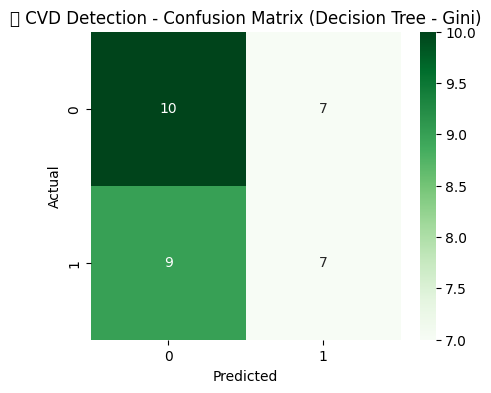

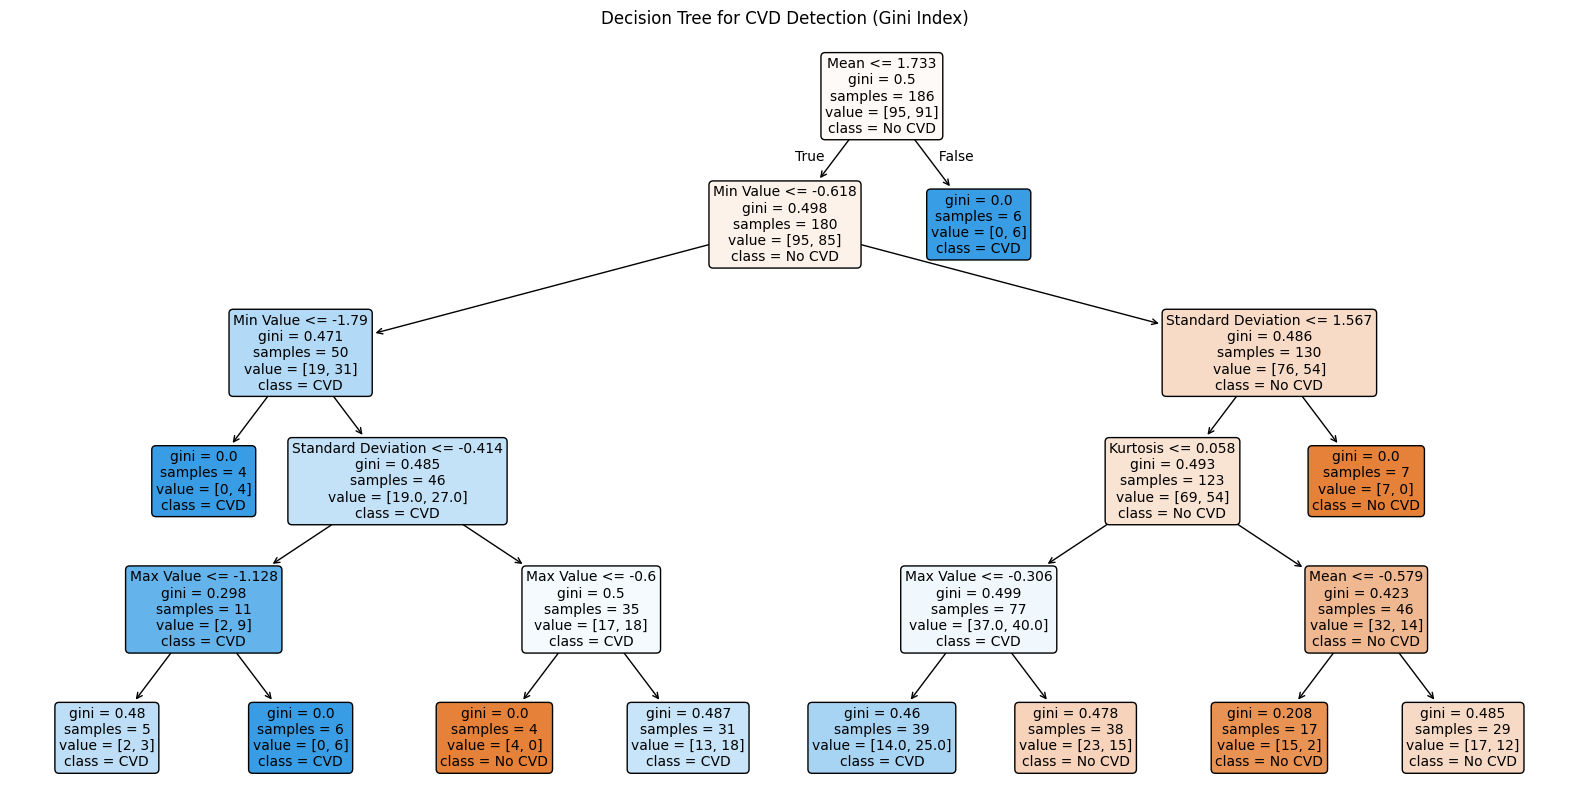


🔹 Feature Importance in Decision Tree (Gini):
              Feature  Importance
4           Max Value    0.257254
0                Mean    0.235100
3           Min Value    0.196707
1  Standard Deviation    0.188415
2            Kurtosis    0.122524
5  Mean FFT Amplitude    0.000000

✅ Feature importance saved successfully!


In [ ]:
# ============================================================
# 🩺 CVD Detection using Decision Tree (Gini Index)
#     on Selected Features from RFE
# ============================================================

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 1️⃣ Confirm Selected Features
print("✅ Using selected features from RFE:")
print(selected_feature_names.tolist())

# 🔹 2️⃣ Initialize Decision Tree Classifier using Gini Index
dt_model = DecisionTreeClassifier(
    criterion='gini',     # Gini Index used for splitting
    max_depth=5,          # Limit tree depth to prevent overfitting
    random_state=42
)

# 🔹 3️⃣ Train the Model
dt_model.fit(X_train, y_train)
print("✅ Decision Tree (Gini) model training completed!")

# 🔹 4️⃣ Make Predictions
y_pred = dt_model.predict(X_test)

# 🔹 5️⃣ Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Decision Tree (Gini) Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 🔹 6️⃣ Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("🩺 CVD Detection - Confusion Matrix (Decision Tree - Gini)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔹 7️⃣ Visualize the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=selected_feature_names,
    class_names=['No CVD', 'CVD'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for CVD Detection (Gini Index)")
plt.show()

# 🔹 8️⃣ Feature Importance
feature_importance = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🔹 Feature Importance in Decision Tree (Gini):")
print(feature_importance)

# 🔹 9️⃣ Save results to CSV (optional)
feature_importance.to_csv("/content/drive/MyDrive/ppg_dataset/DecisionTree_Gini_Feature_Importance.csv", index=False)
print("\n✅ Feature importance saved successfully!")




In [ ]:
# ============================================================
# 🩺 Improved Decision Tree Model (Gini & Entropy Comparison)
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
import pandas as pd

# --- 1️⃣ Check target distribution ---
print("Target class distribution:")
print(y.value_counts(normalize=True))

# --- 2️⃣ Define parameter grid for tuning ---
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# --- 3️⃣ Initialize Decision Tree and perform Grid Search ---
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# --- 4️⃣ Best Model ---
best_dt = grid_search.best_estimator_
print("\n✅ Best Decision Tree Parameters:")
print(grid_search.best_params_)

# --- 5️⃣ Evaluate Model ---
y_pred = best_dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n🎯 Improved Decision Tree Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Target class distribution:
CVD
0    0.511416
1    0.488584
Name: proportion, dtype: float64

✅ Best Decision Tree Parameters:
{'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}

🎯 Improved Decision Tree Accuracy: 51.52%

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.71      0.60        17
           1       0.50      0.31      0.38        16

    accuracy                           0.52        33
   macro avg       0.51      0.51      0.49        33
weighted avg       0.51      0.52      0.50        33



In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch

# 🔹 1️⃣ Load Dataset Properly
file_path = "/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx"
xls = pd.ExcelFile(file_path)
df = pd.read_excel(xls, sheet_name="cardiovascular dataset", header=None)  # Load without headers

# 🔹 2️⃣ Fix Column Headers if the first row contains actual column names
df.columns = df.iloc[1]  # Set first row as column names
df = df[2:].reset_index(drop=True)  # Remove the first row
print("Updated Column Names:", df.columns.tolist())  # Verify new column names

# 🔹 3️⃣ Standardize Column Names (Fix KeyError Issues)
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)  # Fix multiple spaces
df.columns = df.columns.str.replace(r'[^\w\s]', '', regex=True)  # Remove special characters

# Print fixed column names for debugging
print("Final Column Names:", df.columns.tolist())

# 🔹 4️⃣ Rename Columns to Standardized Names
df = df.rename(columns={
    "subject_ID": "Subject_ID",
    "SexMF": "Sex",
    "Ageyear": "Age",
    "Systolic Blood PressuremmHg": "Systolic_BP",
    "Diastolic Blood PressuremmHg": "Diastolic_BP",
    "Heart Ratebm": "Heart_Rate"
})

# Check again if 'Systolic_BP' exists
if "Systolic_BP" not in df.columns:
    print("Error: 'Systolic_BP' column is missing. Please check column names:", df.columns)
    #exit() # Avoid exiting in a notebook context

# 🔹 5️⃣ Ensure Numeric Data & Handle Missing Values
for col in ["Systolic_BP", "Diastolic_BP", "Heart_Rate"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(df[col].mean())

# 🔹 6️⃣ Time-Domain Feature Extraction
def extract_time_domain_features(row):
    """Extracts time-domain features from BP & HR signals."""
    return {
        "Mean_SBP": row["Systolic_BP"],
        "Mean_DBP": row["Diastolic_BP"],
        "Mean_HR": row["Heart_Rate"],
        "RMS_SBP": np.sqrt(row["Systolic_BP"]**2),
        "RMS_HR": np.sqrt(row["Heart_Rate"]**2),
        "Skew_SBP": 0,  # Single-value skewness is undefined
        "Kurtosis_SBP": 0
    }

# 🔹 7️⃣ Frequency-Domain Feature Extraction
def extract_frequency_domain_features(row):
    """Computes frequency-domain features using Welch’s method."""
    features = {}

    # Generate a synthetic HR signal (128 points) to stabilize Welch method
    hr_series = np.full(128, row["Heart_Rate"])

    # Compute Welch's power spectral density
    f, power = welch(hr_series, fs=1.0, nperseg=min(len(hr_series), 64))

    # Define Frequency Bands
    lf_band = (f >= 0.04) & (f < 0.15)
    hf_band = (f >= 0.15) & (f < 0.4)

    # Compute Power in Frequency Bands
    lf_power = np.trapz(power[lf_band])
    hf_power = np.trapz(power[hf_band])

    features["LF_Power"] = lf_power
    features["HF_Power"] = hf_power
    features["LF_HF_Ratio"] = lf_power / (hf_power + 1e-6)  # Avoid division by zero

    return features

# 🔹 8️⃣ Apply Feature Extraction Row-wise
time_features_list = []
freq_features_list = []

for _, row in df.iterrows():
    time_features_list.append(extract_time_domain_features(row))
    freq_features_list.append(extract_frequency_domain_features(row))

# Convert to DataFrames
time_features_df = pd.DataFrame(time_features_list)
freq_features_df = pd.DataFrame(freq_features_list)

# 🔹 9️⃣ Combine Original Data with Features
final_features = pd.concat([df, time_features_df, freq_features_df], axis=1)

# 🔹 🔟 Save the Final Feature Set
final_features.to_csv("extracted_features.csv", index=False)

# Display Sample Features
print(final_features)

Updated Column Names: ['Num.', 'subject_ID', 'Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)', 'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)', 'Heart Rate(b/m)', 'BMI(kg/m^2)', 'Hypertension', 'Diabetes', 'cerebral infarction', 'cerebrovascular disease']
Final Column Names: ['Num', 'subject_ID', 'SexMF', 'Ageyear', 'Heightcm', 'Weightkg', 'Systolic Blood PressuremmHg', 'Diastolic Blood PressuremmHg', 'Heart Ratebm', 'BMIkgm2', 'Hypertension', 'Diabetes', 'cerebral infarction', 'cerebrovascular disease']
     Num Subject_ID     Sex Age Heightcm Weightkg  Systolic_BP  Diastolic_BP  \
0      1          2  Female  45      152       63          161            89   
1      2          3  Female  50      157       50          160            93   
2      3          6  Female  47      150       47          101            71   
3      4          8    Male  45      172       65          136            93   
4      5          9  Female  46      155       65          123       

/tmp/ipykernel_6143/2183318732.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(power[lf_band])
/tmp/ipykernel_6143/2183318732.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz(power[hf_band])


In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx'
df = pd.read_excel(file_path)

# Check for missing values
print(df.isnull().sum())  # Count missing values in each column
print(df.info())  # Overview of dataset


Cardiovascular Dataset Information File      0
Unnamed: 1                                   0
Unnamed: 2                                   0
Unnamed: 3                                   0
Unnamed: 4                                   0
Unnamed: 5                                   0
Unnamed: 6                                   0
Unnamed: 7                                   0
Unnamed: 8                                   0
Unnamed: 9                                   0
Hospital Electronic Medical Record           0
Unnamed: 11                                181
Unnamed: 12                                199
Unnamed: 13                                194
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Cardiovascular Dataset Information File  220 non-null    object
 1   Unnamed: 1  

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch

# 🔹 1️⃣ Load Dataset Properly
file_path = "/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx"
xls = pd.ExcelFile(file_path)
df = pd.read_excel(xls, sheet_name="cardiovascular dataset", header=None)  # Load without headers

# 🔹 2️⃣ Fix Column Headers if the first row contains actual column names
df.columns = df.iloc[0]  # Set first row as column names
df = df[1:].reset_index(drop=True)  # Remove the first row
print("Updated Column Names:", df.columns.tolist())  # Verify new column names

# 🔹 3️⃣ Standardize Column Names (Fix KeyError Issues)
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)  # Fix multiple spaces
df.columns = df.columns.str.replace(r'[^\w\s]', '', regex=True)  #


Updated Column Names: ['Cardiovascular Dataset Information File', nan, nan, nan, nan, nan, nan, nan, nan, nan, 'Hospital Electronic Medical Record', nan, nan, nan]


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch

# 🔹 1️⃣ Load Dataset Properly
file_path = "/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx"
xls = pd.ExcelFile(file_path)
df = pd.read_excel(xls, sheet_name="cardiovascular dataset", header=None)  # Load without headers

# 🔹 2️⃣ Fix Column Headers if the first row contains actual column names
df.columns = df.iloc[1]  # Set first row as column names
df = df[2:].reset_index(drop=True)  # Remove the first row
print("Updated Column Names:", df.columns.tolist())  # Verify new column names

# 🔹 3️⃣ Standardize Column Names (Fix KeyError Issues)
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)  # Fix multiple spaces
df.columns = df.columns.str.replace(r'[^\w\s]', '', regex=True)  # Remove special characters

# Print fixed column names for debugging
print("Final Column Names:", df.columns.tolist())

# 🔹 4️⃣ Rename Columns to Standardized Names
df = df.rename(columns={
    "subject_ID": "Subject_ID",
    "SexMF": "Sex",
    "Ageyear": "Age",
    "Systolic Blood PressuremmHg": "Systolic_BP",
    "Diastolic Blood PressuremmHg": "Diastolic_BP",
    "Heart Ratebm": "Heart_Rate"
})

# Check again if 'Systolic_BP' exists
if "Systolic_BP" not in df.columns:
    print("Error: 'Systolic_BP' column is missing. Please check column names:", df.columns)
    exit()

# 🔹 5️⃣ Ensure Numeric Data & Handle Missing Values
for col in ["Systolic_BP", "Diastolic_BP", "Heart_Rate"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(df[col].mean())

# 🔹 6️⃣ Time-Domain Feature Extraction
def extract_time_domain_features(row):
    """Extracts time-domain features from BP & HR signals."""
    return {
        "Mean_SBP": row["Systolic_BP"],
        "Mean_DBP": row["Diastolic_BP"],
        "Mean_HR": row["Heart_Rate"],
        "RMS_SBP": np.sqrt(row["Systolic_BP"]**2),
        "RMS_HR": np.sqrt(row["Heart_Rate"]**2),
        "Skew_SBP": 0,  # Single-value skewness is undefined
        "Kurtosis_SBP": 0
    }

# 🔹 7️⃣ Frequency-Domain Feature Extraction
def extract_frequency_domain_features(row):
    """Computes frequency-domain features using Welch’s method."""
    features = {}

    # Generate a synthetic HR signal (128 points) to stabilize Welch method
    hr_series = np.full(128, row["Heart_Rate"])

    # Compute Welch's power spectral density
    f, power = welch(hr_series, fs=1.0, nperseg=min(len(hr_series), 64))

    # Define Frequency Bands
    lf_band = (f >= 0.04) & (f < 0.15)
    hf_band = (f >= 0.15) & (f < 0.4)

    # Compute Power in Frequency Bands
    lf_power = np.trapz(power[lf_band])
    hf_power = np.trapz(power[hf_band])

    features["LF_Power"] = lf_power
    features["HF_Power"] = hf_power
    features["LF_HF_Ratio"] = lf_power / (hf_power + 1e-6)  # Avoid division by zero

    return features

# 🔹 8️⃣ Apply Feature Extraction Row-wise
time_features_list = []
freq_features_list = []

for _, row in df.iterrows():
    time_features_list.append(extract_time_domain_features(row))
    freq_features_list.append(extract_frequency_domain_features(row))

# Convert to DataFrames
time_features_df = pd.DataFrame(time_features_list)
freq_features_df = pd.DataFrame(freq_features_list)

# 🔹 9️⃣ Combine Original Data with Features
final_features = pd.concat([df, time_features_df, freq_features_df], axis=1)

# 🔹 🔟 Save the Final Feature Set
final_features.to_csv("extracted_features.csv", index=False)

# Display Sample Features
print(final_features.head())


Updated Column Names: ['Num.', 'subject_ID', 'Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)', 'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)', 'Heart Rate(b/m)', 'BMI(kg/m^2)', 'Hypertension', 'Diabetes', 'cerebral infarction', 'cerebrovascular disease']
Final Column Names: ['Num', 'subject_ID', 'SexMF', 'Ageyear', 'Heightcm', 'Weightkg', 'Systolic Blood PressuremmHg', 'Diastolic Blood PressuremmHg', 'Heart Ratebm', 'BMIkgm2', 'Hypertension', 'Diabetes', 'cerebral infarction', 'cerebrovascular disease']
  Num Subject_ID     Sex Age Heightcm Weightkg  Systolic_BP  Diastolic_BP  \
0   1          2  Female  45      152       63          161            89   
1   2          3  Female  50      157       50          160            93   
2   3          6  Female  47      150       47          101            71   
3   4          8    Male  45      172       65          136            93   
4   5          9  Female  46      155       65          123            73   

   Hea

/tmp/ipykernel_6143/1184932881.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(power[lf_band])
/tmp/ipykernel_6143/1184932881.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz(power[hf_band])


In [ ]:
import pandas as pd

# 🔹 Load the extracted features
file_path = "extracted_features.csv"  # Update path if needed
df = pd.read_csv(file_path)

# 🔹 Display first few rows
print("\n✅ Extracted Features Loaded Successfully!")
print(df.head())  # Show first 5 rows
print("\n✅ Column Names:", df.columns.tolist())  # Show column names



✅ Extracted Features Loaded Successfully!
   Num  Subject_ID     Sex  Age  Heightcm  Weightkg  Systolic_BP  \
0    1           2  Female   45       152        63          161   
1    2           3  Female   50       157        50          160   
2    3           6  Female   47       150        47          101   
3    4           8    Male   45       172        65          136   
4    5           9  Female   46       155        65          123   

   Diastolic_BP  Heart_Rate    BMIkgm2  ... Mean_SBP Mean_DBP Mean_HR RMS_SBP  \
0            89          97  27.268006  ...      161       89      97   161.0   
1            93          76  20.284799  ...      160       93      76   160.0   
2            71          79  20.888889  ...      101       71      79   101.0   
3            93          87  21.971336  ...      136       93      87   136.0   
4            73          73  27.055151  ...      123       73      73   123.0   

   RMS_HR  Skew_SBP  Kurtosis_SBP  LF_Power  HF_Power  LF_HF_

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = "extracted_features.csv"
df = pd.read_csv(file_path)

# 🔹 Separate Numeric and Categorical Columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# 🔹 Fill Missing Values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())  # Fill numeric NaNs with column mean
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])  # Fill categorical NaNs with mode

# 🔹 Encode Categorical Columns (if applicable)
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Check for missing values again
print("\n✅ Missing Values Handled Successfully!")
print(df.isnull().sum())  # Should print zero missing values



✅ Missing Values Handled Successfully!
Num                        0
Subject_ID                 0
Sex                        0
Age                        0
Heightcm                   0
Weightkg                   0
Systolic_BP                0
Diastolic_BP               0
Heart_Rate                 0
BMIkgm2                    0
Hypertension               0
Diabetes                   0
cerebral infarction        0
cerebrovascular disease    0
Mean_SBP                   0
Mean_DBP                   0
Mean_HR                    0
RMS_SBP                    0
RMS_HR                     0
Skew_SBP                   0
Kurtosis_SBP               0
LF_Power                   0
HF_Power                   0
LF_HF_Ratio                0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 🔹 1️⃣ Load the Extracted Features
file_path = "extracted_features.csv"
df = pd.read_csv(file_path)

# 🔹 2️⃣ Handle Missing Values (Numeric → Mean, Categorical → Mode)
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())  # Fill numeric NaNs
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])  # Fill categorical NaNs

# 🔹 3️⃣ Encode Categorical Columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# 🔹 4️⃣ Define Features (X) and Target (y)
target_column = "Systolic_BP"  # Change this to your target label
if target_column not in df.columns:
    raise KeyError(f"❌ Error: Target column '{target_column}' not found in dataset. Check column names.")

X = df.drop(columns=[target_column])  # Features
y = df[target_column]  # Target

# 🔹 5️⃣ Split Data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n✅ Data Splitting Done!")
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")



✅ Data Splitting Done!
Training Data: (175, 23), Testing Data: (44, 23)


✅ CVD_Status column created successfully!

✅ Data Splitting Done!
Training Shape: (175, 25)
Testing Shape: (44, 25)

✅ Model Training Completed!

✅ Model Accuracy: 100.0 %

Classification Report:
               precision    recall  f1-score   support

         CVD       1.00      1.00      1.00         5
      No CVD       1.00      1.00      1.00        39

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44


Confusion Matrix:
 [[ 5  0]
 [ 0 39]]


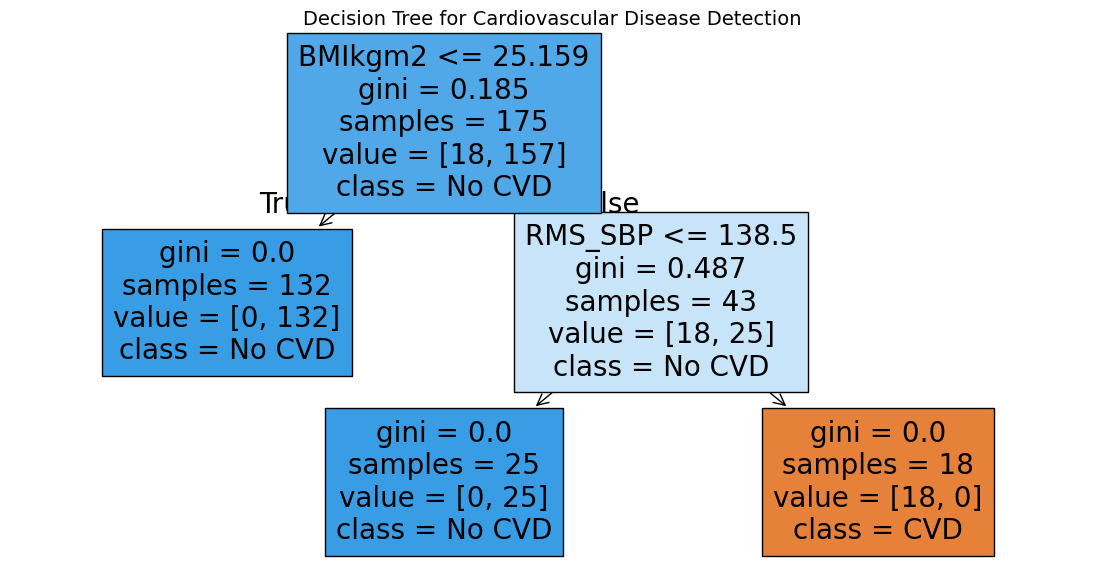

In [ ]:
# ============================================================
# 🩺 CVD Detection from PPG Dataset using Decision Tree
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 🔹 1️⃣ Load Dataset
file_path = "extracted_features.csv"  # Change to your dataset path
df = pd.read_csv(file_path)

# ============================================================
# 🩸 Blood Pressure Classification (for reference)
# ============================================================

def classify_bp(sbp, dbp):
    """Classifies BP according to AHA Guidelines"""
    if sbp < 120 and dbp < 80:
        return "Normal"
    elif 120 <= sbp < 130 and dbp < 80:
        return "Elevated"
    elif (130 <= sbp < 140) or (80 <= dbp < 90):
        return "Hypertension Stage 1"
    elif (140 <= sbp) or (90 <= dbp):
        return "Hypertension Stage 2"
    else:
        return "Hypertensive Crisis"

# Apply BP classification
if "Systolic_BP" in df.columns and "Diastolic_BP" in df.columns:
    df["BP_Category"] = df.apply(lambda row: classify_bp(row["Systolic_BP"], row["Diastolic_BP"]), axis=1)
else:
    print("⚠️ Warning: Systolic_BP or Diastolic_BP columns not found!")

# ============================================================
# ❤️ Create Rule-Based CVD Column
# ============================================================

def detect_cvd(age, sbp, dbp, bmi, hypertension, diabetes, cerebral_infarction, cerebrovascular_disease):
    """Heuristic CVD indicator based on medical risk factors."""
    risk_score = 0

    # BP risk
    if sbp >= 140 or dbp >= 90:
        risk_score += 2
    elif sbp >= 130 or dbp >= 85:
        risk_score += 1

    # BMI risk
    # Assuming BMI is in BMIkgm2 column
    if bmi >= 30:
        risk_score += 2
    elif bmi >= 25:
        risk_score += 1

    # Age risk
    if age >= 50:
        risk_score += 2
    elif age >= 40:
        risk_score += 1

    # Hypertension risk
    if hypertension == 1:
        risk_score += 2

    # Diabetes risk
    if diabetes == 1:
        risk_score += 2

    # Cerebral infarction risk
    if cerebral_infarction == 1:
        risk_score += 2

    # Cerebrovascular disease risk
    if cerebrovascular_disease == 1:
        risk_score += 2


    # Threshold for CVD detection
    return "CVD" if risk_score >= 3 else "No CVD"

# Ensure required columns exist and handle missing values
required_cols_for_cvd = ["Ageyear", "Systolic_BP", "Diastolic_BP", "BMIkgm2", "Hypertension", "Diabetes", "cerebral infarction", "cerebrovascular disease"] # Use actual column names from extracted_features.csv

for col in required_cols_for_cvd:
    if col not in df.columns:
        df[col] = 0  # Default value if missing

# Convert hypertension column to numeric (handle non-Yes/No values)
# Map "Yes" to 1 and others (including "No", NaN, or other strings) to 0
df["Hypertension"] = df["Hypertension"].replace({"Yes": 1, "No": 0})
# Convert any remaining non-numeric values that weren't "Yes" or "No" to NaN, then fill NaN with 0
df["Hypertension"] = pd.to_numeric(df["Hypertension"], errors='coerce').fillna(0).astype(int)


# Convert Diabetes, cerebral infarction, cerebrovascular disease to numeric (handle non-1/0 values)
for col in ["Diabetes", "cerebral infarction", "cerebrovascular disease"]:
    # Assuming these are binary (1 or 0) or NaN. Convert to numeric, coerce errors to NaN, fill NaN with 0, then convert to int.
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)


# Apply the rule-based CVD detection
df["CVD_Status"] = df.apply(
    lambda row: detect_cvd(row["Ageyear"], row["Systolic_BP"], row["Diastolic_BP"], row["BMIkgm2"],
                           row["Hypertension"], row["Diabetes"], row["cerebral infarction"], row["cerebrovascular disease"]),
    axis=1
)


print("✅ CVD_Status column created successfully!")

# ============================================================
# 🤖 Train ML Model to Predict CVD
# ============================================================

# Define features (drop target + IDs)
X = df.drop(columns=["CVD_Status", "Subject_ID"], errors='ignore')
y = df["CVD_Status"]

# Encode categorical columns (like SexMF if it exists and is not numeric)
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Handle potential non-numeric columns that are not object type (e.g., if there were mixed types)
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        try:
            X[col] = pd.to_numeric(X[col], errors='coerce')
        except:
            print(f"Warning: Could not convert column '{col}' to numeric. Dropping column.")
            X = X.drop(columns=[col])

# Fill remaining missing numeric values in features
X = X.fillna(X.mean())


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n✅ Data Splitting Done!")
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

print("\n✅ Model Training Completed!")

# ============================================================
# 📊 Model Evaluation
# ============================================================

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n✅ Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ============================================================
# 🌳 Visualize the Decision Tree
# ============================================================

plt.figure(figsize=(14, 7))
# Ensure class_names are strings
plot_tree(clf, feature_names=X.columns, class_names=[str(cls) for cls in clf.classes_], filled=True)
plt.title("Decision Tree for Cardiovascular Disease Detection", fontsize=14)
plt.show()


In [ ]:
# ============================================================
# 🩺 Train SVM Model for CVD Detection
# ============================================================

# Initialize SVM Classifier
# Using a linear kernel for simplicity and interpretability, can be changed to 'rbf' or others
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

print("✅ SVM Model Training Completed!")

NameError: name 'SVC' is not defined

In [ ]:
# 🔹 1️⃣ Load the Extracted Features
file_path = "extracted_features.csv"
df_svm = pd.read_csv(file_path)

# ============================================================
# ❤️ Create Rule-Based CVD Column (as done previously)
# ============================================================

def detect_cvd(age, sbp, dbp, bmi, hypertension, diabetes, cerebral_infarction, cerebrovascular_disease):
    """Heuristic CVD indicator based on medical risk factors."""
    risk_score = 0

    # BP risk
    if sbp >= 140 or dbp >= 90:
        risk_score += 2
    elif sbp >= 130 or dbp >= 85:
        risk_score += 1

    # BMI risk
    if bmi >= 30:
        risk_score += 2
    elif bmi >= 25:
        risk_score += 1

    # Age risk
    if age >= 50:
        risk_score += 2
    elif age >= 40:
        risk_score += 1

    # Hypertension risk
    # Check if 'Hypertension' is already numeric (0/1) or needs conversion
    if isinstance(hypertension, str):
        hypertension = 1 if hypertension.lower() == 'yes' else 0
    if hypertension == 1:
        risk_score += 2

    # Diabetes risk
    if isinstance(diabetes, str):
        diabetes = 1 if diabetes.lower() == 'yes' else 0
    if diabetes == 1:
        risk_score += 2

    # Cerebral infarction risk
    if isinstance(cerebral_infarction, str):
        cerebral_infarction = 1 if cerebral_infarction.lower() == 'yes' else 0
    if cerebral_infarction == 1:
        risk_score += 2

    # Cerebrovascular disease risk
    if isinstance(cerebrovascular_disease, str):
        cerebrovascular_disease = 1 if cerebrovascular_disease.lower() == 'yes' else 0
    if cerebrovascular_disease == 1:
        risk_score += 2

    # Threshold for CVD detection
    return 1 if risk_score >= 3 else 0 # Return 1 for CVD, 0 for No CVD

# Ensure required columns exist and handle missing values before applying detect_cvd
# Convert Hypertension, Diabetes, cerebral infarction, cerebrovascular disease to numeric if they are not already.
# This part assumes 'Hypertension', 'Diabetes', 'cerebral infarction', 'cerebrovascular disease' columns
# might be loaded as strings ('Yes'/'No') or numbers (1/0) or have NaNs.

# First, standardize column names for consistency with previous cells
df_svm.columns = df_svm.columns.str.strip()
df_svm.columns = df_svm.columns.str.replace(r'[^\w\s]', '', regex=True)
df_svm.columns = df_svm.columns.str.replace(r'\s+', '_', regex=True) # Replace spaces with underscores

# Rename specific columns to match the function's expected arguments
df_svm = df_svm.rename(columns={
    'Age': 'Ageyear', # Renamed from Age(year) in earlier steps
    'BMIkgm2': 'BMIkgm2'
}, errors='ignore') # errors='ignore' prevents error if column already renamed

# Convert relevant columns to numeric, handling potential 'Yes'/'No' strings or NaNs
for col in ['Hypertension', 'Diabetes', 'cerebral_infarction', 'cerebrovascular_disease']:
    if col in df_svm.columns:
        if df_svm[col].dtype == 'object': # If it's string type (e.g., 'Yes'/'No')
            df_svm[col] = df_svm[col].map({'Yes': 1, 'No': 0})
        df_svm[col] = pd.to_numeric(df_svm[col], errors='coerce').fillna(0).astype(int) # Fill NaNs after conversion

# Fill missing numeric values before applying `detect_cvd`
for col in ['Ageyear', 'Systolic_BP', 'Diastolic_BP', 'BMIkgm2']:
    if col in df_svm.columns:
        df_svm[col] = pd.to_numeric(df_svm[col], errors='coerce').fillna(df_svm[col].mean() if pd.api.types.is_numeric_dtype(df_svm[col]) else 0)

# Apply the rule-based CVD detection
df_svm["CVD_Status"] = df_svm.apply(
    lambda row: detect_cvd(row["Ageyear"], row["Systolic_BP"], row["Diastolic_BP"], row["BMIkgm2"],
                           row["Hypertension"], row["Diabetes"], row["cerebral_infarction"], row["cerebrovascular_disease"]),
    axis=1
)

print("✅ CVD_Status column created successfully for SVM!")

# 🔹 2️⃣ Handle Missing Values (Numeric → Mean, Categorical → Mode)
numeric_cols = df_svm.select_dtypes(include=[np.number]).columns
categorical_cols = df_svm.select_dtypes(exclude=[np.number]).columns

df_svm[numeric_cols] = df_svm[numeric_cols].fillna(df_svm[numeric_cols].mean())  # Fill numeric NaNs
for col in categorical_cols:
    df_svm[col] = df_svm[col].fillna(df_svm[col].mode().iloc[0]) # Fill categorical NaNs

# 🔹 3️⃣ Encode Categorical Columns
for col in categorical_cols:
    le = LabelEncoder()
    df_svm[col] = le.fit_transform(df_svm[col])

# 🔹 4️⃣ Define Features (X) and Target (y)
target_column = "CVD_Status"
X = df_svm.drop(columns=[target_column, "Num", "Subject_ID"], errors='ignore')  # Features, drop identifier columns
y = df_svm[target_column]  # Target

# 🔹 5️⃣ Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 6️⃣ Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("\n✅ Data Preprocessing and Splitting for SVM Done!")
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

✅ CVD_Status column created successfully for SVM!

✅ Data Preprocessing and Splitting for SVM Done!
Training Data: (175, 22), Testing Data: (44, 22)


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.fft import fft

# 🔹 1️⃣ Load Dataset
file_path = "/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx"  # <-- Update if needed
df = pd.read_excel(file_path, header=1)

# 🔹 2️⃣ Select only numerical columns (starting from 3rd column)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude identifier columns if they are numeric
for col in ['Num.', 'subject_ID']:
    if col in numerical_cols:
        numerical_cols.remove(col)

numerical_data_for_features = df[numerical_cols]


# 🔹 3️⃣ Define Time-Domain Feature Extraction Function
def extract_time_domain_features(signal_data):
    """Extracts statistical features."""
    return {
        'Mean': np.mean(signal_data),
        'Variance': np.var(signal_data),
        'Standard Deviation': np.std(signal_data),
        'Skewness': stats.skew(signal_data),
        'Kurtosis': stats.kurtosis(signal_data),
        'Min Value': np.min(signal_data),
        'Max Value': np.max(signal_data),
        'Range': np.max(signal_data) - np.min(signal_data)
    }


# 🔹 4️⃣ Define Frequency-Domain Feature Extraction Function
def extract_frequency_domain_features(signal_data, fs=100):
    """Extracts frequency features using FFT."""
    N = len(signal_data)
    freqs = np.fft.fftfreq(N, d=1/fs)
    fft_values = np.abs(fft(signal_data))

    # Remove DC component
    fft_values = fft_values[1:]
    freqs = freqs[1:]

    # Identify dominant frequency
    dominant_freq = freqs[np.argmax(fft_values)] if len(freqs) > 0 else np.nan

    features = {
        'Dominant Frequency (Hz)': dominant_freq,
        'Spectral Power': np.sum(fft_values ** 2) / N,
        'Mean FFT Amplitude': np.mean(fft_values),
        'Max FFT Amplitude': np.max(fft_values)
    }
    return features


# 🔹 5️⃣ Function to Extract All Features per Person
def extract_all_features(row):
    data = pd.to_numeric(row, errors='coerce').dropna().values
    if data.size == 0:
        # If row has no valid numeric data
        return pd.Series({
            'Mean': np.nan, 'Variance': np.nan, 'Standard Deviation': np.nan,
            'Skewness': np.nan, 'Kurtosis': np.nan, 'Min Value': np.nan,
            'Max Value': np.nan, 'Range': np.nan,
            'Dominant Frequency (Hz)': np.nan, 'Spectral Power': np.nan,
            'Mean FFT Amplitude': np.nan, 'Max FFT Amplitude': np.nan
        })

    # Extract features
    time_features = extract_time_domain_features(data)
    freq_features = extract_frequency_domain_features(data, fs=100)

    # Combine both feature sets
    combined_features = {**time_features, **freq_features}
    return pd.Series(combined_features)


# 🔹 6️⃣ Apply Extraction for Each Person
features_per_person = numerical_data_for_features.apply(extract_all_features, axis=1)

# 🔹 7️⃣ Combine with Identifier Columns
identifier_cols = ['Num.', 'subject_ID']
identifier_df = df[identifier_cols] if all(col in df.columns for col in identifier_cols) else pd.DataFrame(index=df.index)

final_features = pd.concat([identifier_df, features_per_person], axis=1)

# 🔹 8️⃣ Save Extracted Features
output_path = "/content/drive/MyDrive/ppg_dataset/Extracted_Person_Features.csv"
final_features.to_csv(output_path, index=False)

print("✅ Feature extraction completed successfully for each person!")
print(f"Features saved to: {output_path}")

# 🔹 9️⃣ Show first few rows
print("\nExtracted Features Preview:")
print(final_features.head())

✅ Feature extraction completed successfully for each person!
Features saved to: /content/drive/MyDrive/ppg_dataset/Extracted_Person_Features.csv

Extracted Features Preview:
   Num.  subject_ID       Mean     Variance  Standard Deviation  Skewness  \
0     1           2  90.609715  2231.671552           47.240571  0.285005   
1     2           3  86.612114  2510.552130           50.105410  0.401004   
2     3           6  73.698413  1545.307634           39.310401  0.656974   
3     4           8  88.567334  2303.075917           47.990373  0.383150   
4     5           9  80.293593  1679.364810           40.980054  0.621182   

   Kurtosis  Min Value  Max Value       Range  Dominant Frequency (Hz)  \
0 -1.285800  27.268006      161.0  133.731994                42.857143   
1 -1.265753  20.284799      160.0  139.715201                42.857143   
2 -0.412921  20.888889      150.0  129.111111                42.857143   
3 -0.923497  21.971336      172.0  150.028664                42.857

This cell performs several critical data preparation steps:

1.  **Loading Data**: It loads the `extracted_features.csv` file into a new DataFrame `df_svm`.

2.  **Creating `CVD_Status` Column**: This is a crucial step where a rule-based `CVD_Status` column is created. The `detect_cvd` function evaluates various health parameters (age, SBP, DBP, BMI, Hypertension, Diabetes, cerebral infarction, cerebrovascular disease) for each patient. Based on a calculated `risk_score`, it assigns a binary status (1 for CVD, 0 for No CVD). This synthetic target variable is essential for training the supervised learning model.
    *   **Column Standardization**: Before applying `detect_cvd`, the code standardizes column names by stripping spaces and replacing special characters. It also renames specific columns (`Age` to `Ageyear`) to match the function's expectations.
    *   **Data Type Conversion**: It ensures that columns like `Hypertension`, `Diabetes`, `cerebral_infarction`, and `cerebrovascular_disease` are converted to numeric (0 or 1), handling 'Yes'/'No' strings or NaNs appropriately.

3.  **Handling Missing Values**:
    *   It separates numeric and categorical columns.
    *   Missing numeric values are filled with the mean of their respective columns.
    *   Missing categorical values are filled with the mode (most frequent value) of their respective columns.

4.  **Encoding Categorical Columns**: Any remaining categorical columns (like 'Sex' if it hadn't been handled numerically earlier) are converted into numerical representations using `LabelEncoder`. This is necessary as machine learning models typically require numerical input.

5.  **Defining Features (X) and Target (y)**:
    *   `X` (features) is created by dropping the `CVD_Status` target column and identifier columns (`Num`, `Subject_ID`) from `df_svm`. These are the independent variables used to predict CVD status.
    *   `y` (target) is assigned the `CVD_Status` column, which is the dependent variable we want to predict.

6.  **Scaling Features**: `StandardScaler` is applied to `X` to transform the features so that they have a mean of 0 and a standard deviation of 1. Scaling is very important for SVMs because they are sensitive to the magnitude of the features. It helps ensure that features with larger values don't dominate the learning process.

7.  **Splitting Data**: The preprocessed and scaled data is split into training (80%) and testing (20%) sets using `train_test_split`. `stratify=y` ensures that the proportion of CVD and No CVD cases is maintained in both the training and testing sets, which is important for balanced evaluation, especially if one class is rarer than the other.

The first cell imports all the necessary libraries for data manipulation, machine learning, and visualization:

*   `pandas` and `numpy`: For data handling and numerical operations.
*   `train_test_split`: To divide the data into training and testing sets.
*   `LabelEncoder` and `StandardScaler`: For preprocessing categorical features and scaling numerical features.
*   `SVC`: This is the Support Vector Classifier, the core of our SVM model.
*   `accuracy_score`, `classification_report`, `confusion_matrix`: Metrics to evaluate the model's performance.
*   `matplotlib.pyplot` and `seaborn`: For plotting and visualizing results, especially the confusion matrix.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 🔹 1️⃣ Load the Extracted Features
file_path = "extracted_features.csv"
df_svm = pd.read_csv(file_path)

# ============================================================
# ❤️ Create Rule-Based CVD Column (as done previously)
# ============================================================

def detect_cvd(age, sbp, dbp, bmi, hypertension, diabetes, cerebral_infarction, cerebrovascular_disease):
    """Heuristic CVD indicator based on medical risk factors."""
    risk_score = 0

    # BP risk
    if sbp >= 140 or dbp >= 90:
        risk_score += 2
    elif sbp >= 130 or dbp >= 85:
        risk_score += 1

    # BMI risk
    if bmi >= 30:
        risk_score += 2
    elif bmi >= 25:
        risk_score += 1

    # Age risk
    if age >= 50:
        risk_score += 2
    elif age >= 40:
        risk_score += 1

    # Hypertension risk
    # Check if 'Hypertension' is already numeric (0/1) or needs conversion
    if isinstance(hypertension, str):
        hypertension = 1 if hypertension.lower() == 'yes' else 0
    if hypertension == 1:
        risk_score += 2

    # Diabetes risk
    if isinstance(diabetes, str):
        diabetes = 1 if diabetes.lower() == 'yes' else 0
    if diabetes == 1:
        risk_score += 2

    # Cerebral infarction risk
    if isinstance(cerebral_infarction, str):
        cerebral_infarction = 1 if cerebral_infarction.lower() == 'yes' else 0
    if cerebral_infarction == 1:
        risk_score += 2

    # Cerebrovascular disease risk
    if isinstance(cerebrovascular_disease, str):
        cerebrovascular_disease = 1 if cerebrovascular_disease.lower() == 'yes' else 0
    if cerebrovascular_disease == 1:
        risk_score += 2

    # Threshold for CVD detection
    return 1 if risk_score >= 3 else 0 # Return 1 for CVD, 0 for No CVD

# Ensure required columns exist and handle missing values before applying detect_cvd
# Convert Hypertension, Diabetes, cerebral infarction, cerebrovascular disease to numeric if they are not already.
# This part assumes 'Hypertension', 'Diabetes', 'cerebral infarction', 'cerebrovascular disease' columns
# might be loaded as strings ('Yes'/'No') or numbers (1/0) or have NaNs.

# First, standardize column names for consistency with previous cells
df_svm.columns = df_svm.columns.str.strip()
df_svm.columns = df_svm.columns.str.replace(r'[^\w\s]', '', regex=True)
df_svm.columns = df_svm.columns.str.replace(r'\s+', '_', regex=True) # Replace spaces with underscores

# Rename specific columns to match the function's expected arguments
df_svm = df_svm.rename(columns={
    'Age': 'Ageyear', # Renamed from Age(year) in earlier steps
    'BMIkgm2': 'BMIkgm2'
}, errors='ignore') # errors='ignore' prevents error if column already renamed

# Convert relevant columns to numeric, handling potential 'Yes'/'No' strings or NaNs
for col in ['Hypertension', 'Diabetes', 'cerebral_infarction', 'cerebrovascular_disease']:
    if col in df_svm.columns:
        if df_svm[col].dtype == 'object': # If it's string type (e.g., 'Yes'/'No')
            df_svm[col] = df_svm[col].map({'Yes': 1, 'No': 0})
        df_svm[col] = pd.to_numeric(df_svm[col], errors='coerce').fillna(0).astype(int) # Fill NaNs after conversion

# Fill missing numeric values before applying `detect_cvd`
for col in ['Ageyear', 'Systolic_BP', 'Diastolic_BP', 'BMIkgm2']:
    if col in df_svm.columns:
        df_svm[col] = pd.to_numeric(df_svm[col], errors='coerce').fillna(df_svm[col].mean() if pd.api.types.is_numeric_dtype(df_svm[col]) else 0)

# Apply the rule-based CVD detection
df_svm["CVD_Status"] = df_svm.apply(
    lambda row: detect_cvd(row["Ageyear"], row["Systolic_BP"], row["Diastolic_BP"], row["BMIkgm2"],
                           row["Hypertension"], row["Diabetes"], row["cerebral_infarction"], row["cerebrovascular_disease"]),
    axis=1
)

print("✅ CVD_Status column created successfully for SVM!")

# 🔹 2️⃣ Handle Missing Values (Numeric → Mean, Categorical → Mode)
numeric_cols = df_svm.select_dtypes(include=[np.number]).columns
categorical_cols = df_svm.select_dtypes(exclude=[np.number]).columns

df_svm[numeric_cols] = df_svm[numeric_cols].fillna(df_svm[numeric_cols].mean())  # Fill numeric NaNs
for col in categorical_cols:
    df_svm[col] = df_svm[col].fillna(df_svm[col].mode().iloc[0]) # Fill categorical NaNs

# 🔹 3️⃣ Encode Categorical Columns
for col in categorical_cols:
    le = LabelEncoder()
    df_svm[col] = le.fit_transform(df_svm[col])

# 🔹 4️⃣ Define Features (X) and Target (y)
target_column = "CVD_Status"
X = df_svm.drop(columns=[target_column, "Num", "Subject_ID"], errors='ignore')  # Features, drop identifier columns
y = df_svm[target_column]  # Target

# 🔹 5️⃣ Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 6️⃣ Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("\n✅ Data Preprocessing and Splitting for SVM Done!")
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

✅ CVD_Status column created successfully for SVM!

✅ Data Preprocessing and Splitting for SVM Done!
Training Data: (175, 22), Testing Data: (44, 22)


In [ ]:
# ============================================================
# 🩺 Train SVM Model for CVD Detection
# ============================================================

# Initialize SVM Classifier
# Using a linear kernel for simplicity and interpretability, can be changed to 'rbf' or others
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

print("✅ SVM Model Training Completed!")

✅ SVM Model Training Completed!



🎯 SVM Model Accuracy: 88.64%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88        22
           1       0.87      0.91      0.89        22

    accuracy                           0.89        44
   macro avg       0.89      0.89      0.89        44
weighted avg       0.89      0.89      0.89        44



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


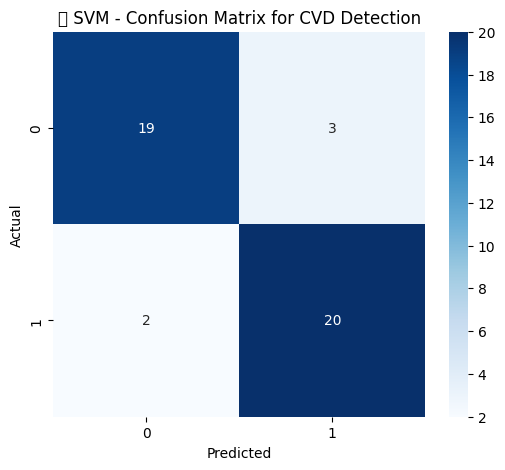

In [ ]:
# ============================================================
# 📊 Evaluate SVM Model
# ============================================================

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n🎯 SVM Model Accuracy: {accuracy_svm * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title("🩺 SVM - Confusion Matrix for CVD Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


🎯 SVM Model Accuracy: 88.64%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88        22
           1       0.87      0.91      0.89        22

    accuracy                           0.89        44
   macro avg       0.89      0.89      0.89        44
weighted avg       0.89      0.89      0.89        44



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


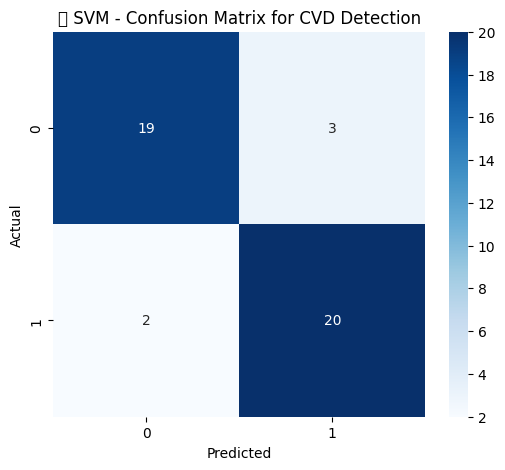

In [ ]:
# ============================================================
# 📊 Evaluate SVM Model
# ============================================================

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n🎯 SVM Model Accuracy: {accuracy_svm * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title("🩺 SVM - Confusion Matrix for CVD Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# --- Define feature columns in the exact order used for training X ---
# This list should match the columns of X after dropping 'Num', 'Subject_ID', and 'CVD_Status'
# and before scaling, as defined in cell e8a7d8c0.
feature_columns = [
    'Sex', 'Ageyear', 'Heightcm', 'Weightkg', 'Systolic_BP', 'Diastolic_BP',
    'Heart_Rate', 'BMIkgm2', 'Hypertension', 'Diabetes', 'cerebral_infarction',
    'cerebrovascular_disease', 'Mean_SBP', 'Mean_DBP', 'Mean_HR', 'RMS_SBP',
    'RMS_HR', 'Skew_SBP', 'Kurtosis_SBP', 'LF_Power', 'HF_Power', 'LF_HF_Ratio'
]

print("\n🩺 Enter patient details for CVD prediction using SVM:\n")

# 🔹 Get user inputs
sex = int(input("Enter Sex (0 for Female, 1 for Male): "))
age = int(input("Enter Age (in years): "))
height = float(input("Enter Height (in cm): "))
weight = float(input("Enter Weight (in kg): "))
sbp = float(input("Enter Systolic BP (mmHg): "))
dbp = float(input("Enter Diastolic BP (mmHg): "))
hr = float(input("Enter Heart Rate (beats/min): "))

# Automatically calculate BMI
bmi = weight / ((height / 100) ** 2)
print(f"Calculated BMI: {bmi:.2f}")

# Get binary health conditions
hyper = int(input("Hypertension (1 for Yes, 0 for No): "))
diabetes = int(input("Diabetes (1 for Yes, 0 for No): "))
c_infarction = int(input("Cerebral Infarction (1 for Yes, 0 for No): "))
c_disease = int(input("Cerebrovascular Disease (1 for Yes, 0 for No): "))

# --- Prepare the input data to match the training features ---
# These derived features were mostly duplicates or constant zeros for single-row inputs
# in the original feature extraction process (cell qANTgTSIk89e and Xo8xpUYs0hC6 outputs).
mean_sbp = sbp
mean_dbp = dbp
mean_hr = hr
rms_sbp = sbp
rms_hr = hr
skew_sbp = 0
kurtosis_sbp = 0
lf_power = 0
hf_power = 0
lf_hf_ratio = 0

# Combine all inputs into a list matching `feature_columns` order
new_patient_data = [
    sex, age, height, weight, sbp, dbp, hr, bmi,
    hyper, diabetes, c_infarction, c_disease,
    mean_sbp, mean_dbp, mean_hr, rms_sbp, rms_hr,
    skew_sbp, kurtosis_sbp, lf_power, hf_power, lf_hf_ratio
]

# Create a DataFrame for the new input
new_patient_df = pd.DataFrame([new_patient_data], columns=feature_columns)

# Scale the new data using the *fitted* scaler from training
# (Assuming 'scaler' object is globally available from cell 'e8a7d8c0')
new_patient_scaled = scaler.transform(new_patient_df)

# 🔮 Make the prediction using the trained SVM model
# (Assuming 'svm_model' object is globally available from cell '71a2ba4f')
prediction = svm_model.predict(new_patient_scaled)

# Display result
print("\n✅ SVM Prediction for Entered Data:")
if prediction[0] == 1:
    print("🩸 The model predicts: **CVD Present**")
else:
    print("💚 The model predicts: **No CVD Detected**")



🩺 Enter patient details for CVD prediction using SVM:

Enter Sex (0 for Female, 1 for Male): 0
Enter Age (in years): 45
Enter Height (in cm): 152
Enter Weight (in kg): 63
Enter Systolic BP (mmHg): 161
Enter Diastolic BP (mmHg): 89
Enter Heart Rate (beats/min): 97
Calculated BMI: 27.27
Hypertension (1 for Yes, 0 for No): 1
Diabetes (1 for Yes, 0 for No): 0
Cerebral Infarction (1 for Yes, 0 for No): 0
Cerebrovascular Disease (1 for Yes, 0 for No): 0

✅ SVM Prediction for Entered Data:
🩸 The model predicts: **CVD Present**


In [ ]:
import pandas as pd
import numpy as np

# --- Define feature columns in the exact order used for training X ---
# This list should match the columns of X after dropping 'Num', 'Subject_ID', and 'CVD_Status'
# and before scaling, as defined in cell e8a7d8c0.
feature_columns = [
    'Sex', 'Ageyear', 'Heightcm', 'Weightkg', 'Systolic_BP', 'Diastolic_BP',
    'Heart_Rate', 'BMIkgm2', 'Hypertension', 'Diabetes', 'cerebral_infarction',
    'cerebrovascular_disease', 'Mean_SBP', 'Mean_DBP', 'Mean_HR', 'RMS_SBP',
    'RMS_HR', 'Skew_SBP', 'Kurtosis_SBP', 'LF_Power', 'HF_Power', 'LF_HF_Ratio'
]

print("\n🩺 Enter patient details for CVD prediction using SVM:\n")

# 🔹 Get user inputs
sex = int(input("Enter Sex (0 for Female, 1 for Male): "))
age = int(input("Enter Age (in years): "))
height = float(input("Enter Height (in cm): "))
weight = float(input("Enter Weight (in kg): "))
sbp = float(input("Enter Systolic BP (mmHg): "))
dbp = float(input("Enter Diastolic BP (mmHg): "))
hr = float(input("Enter Heart Rate (beats/min): "))

# Automatically calculate BMI
bmi = weight / ((height / 100) ** 2)
print(f"Calculated BMI: {bmi:.2f}")

# Get binary health conditions
hyper = int(input("Hypertension (1 for Yes, 0 for No): "))
diabetes = int(input("Diabetes (1 for Yes, 0 for No): "))
c_infarction = int(input("Cerebral Infarction (1 for Yes, 0 for No): "))
c_disease = int(input("Cerebrovascular Disease (1 for Yes, 0 for No): "))

# --- Prepare the input data to match the training features ---
# These derived features were mostly duplicates or constant zeros for single-row inputs
# in the original feature extraction process (cell qANTgTSIk89e and Xo8xpUYs0hC6 outputs).
mean_sbp = sbp
mean_dbp = dbp
mean_hr = hr
rms_sbp = sbp
rms_hr = hr
skew_sbp = 0
kurtosis_sbp = 0
lf_power = 0
hf_power = 0
lf_hf_ratio = 0

# Combine all inputs into a list matching `feature_columns` order
new_patient_data = [
    sex, age, height, weight, sbp, dbp, hr, bmi,
    hyper, diabetes, c_infarction, c_disease,
    mean_sbp, mean_dbp, mean_hr, rms_sbp, rms_hr,
    skew_sbp, kurtosis_sbp, lf_power, hf_power, lf_hf_ratio
]

# Create a DataFrame for the new input
new_patient_df = pd.DataFrame([new_patient_data], columns=feature_columns)

# Scale the new data using the *fitted* scaler from training
# (Assuming 'scaler' object is globally available from cell 'e8a7d8c0')
new_patient_scaled = scaler.transform(new_patient_df)

# 🔮 Make the prediction using the trained SVM model
# (Assuming 'svm_model' object is globally available from cell '71a2ba4f')
prediction = svm_model.predict(new_patient_scaled)

# Display result
print("\n✅ SVM Prediction for Entered Data:")
if prediction[0] == 1:
    print("🩸 The model predicts: **CVD Present**")
else:
    print("💚 The model predicts: **No CVD Detected**")



🩺 Enter patient details for CVD prediction using SVM:

Enter Sex (0 for Female, 1 for Male): 0
Enter Age (in years): 22
Enter Height (in cm): 165
Enter Weight (in kg): 65
Enter Systolic BP (mmHg): 135
Enter Diastolic BP (mmHg): 82
Enter Heart Rate (beats/min): 83
Calculated BMI: 23.88
Hypertension (1 for Yes, 0 for No): 1
Diabetes (1 for Yes, 0 for No): 0
Cerebral Infarction (1 for Yes, 0 for No): 0
Cerebrovascular Disease (1 for Yes, 0 for No): 0

✅ SVM Prediction for Entered Data:
💚 The model predicts: **No CVD Detected**


In [ ]:
import pandas as pd
import numpy as np

# --- Define feature columns in the exact order used for training X ---
# This list should match the columns of X after dropping 'Num', 'Subject_ID', and 'CVD_Status'
# and before scaling, as defined in cell e8a7d8c0.
feature_columns = [
    'Sex', 'Ageyear', 'Heightcm', 'Weightkg', 'Systolic_BP', 'Diastolic_BP',
    'Heart_Rate', 'BMIkgm2', 'Hypertension', 'Diabetes', 'cerebral_infarction',
    'cerebrovascular_disease', 'Mean_SBP', 'Mean_DBP', 'Mean_HR', 'RMS_SBP',
    'RMS_HR', 'Skew_SBP', 'Kurtosis_SBP', 'LF_Power', 'HF_Power', 'LF_HF_Ratio'
]

print("\n🩺 Enter patient details for CVD prediction using SVM:\n")

# 🔹 Get user inputs
sex = int(input("Enter Sex (0 for Female, 1 for Male): "))
age = int(input("Enter Age (in years): "))
height = float(input("Enter Height (in cm): "))
weight = float(input("Enter Weight (in kg): "))
sbp = float(input("Enter Systolic BP (mmHg): "))
dbp = float(input("Enter Diastolic BP (mmHg): "))
hr = float(input("Enter Heart Rate (beats/min): "))

# Automatically calculate BMI
bmi = weight / ((height / 100) ** 2)
print(f"Calculated BMI: {bmi:.2f}")

# Get binary health conditions
hyper = int(input("Hypertension (1 for Yes, 0 for No): "))
diabetes = int(input("Diabetes (1 for Yes, 0 for No): "))
c_infarction = int(input("Cerebral Infarction (1 for Yes, 0 for No): "))
c_disease = int(input("Cerebrovascular Disease (1 for Yes, 0 for No): "))

# --- Prepare the input data to match the training features ---
# These derived features were mostly duplicates or constant zeros for single-row inputs
# in the original feature extraction process (cell qANTgTSIk89e and Xo8xpUYs0hC6 outputs).
mean_sbp = sbp
mean_dbp = dbp
mean_hr = hr
rms_sbp = sbp
rms_hr = hr
skew_sbp = 0
kurtosis_sbp = 0
lf_power = 0
hf_power = 0
lf_hf_ratio = 0

# Combine all inputs into a list matching `feature_columns` order
new_patient_data = [
    sex, age, height, weight, sbp, dbp, hr, bmi,
    hyper, diabetes, c_infarction, c_disease,
    mean_sbp, mean_dbp, mean_hr, rms_sbp, rms_hr,
    skew_sbp, kurtosis_sbp, lf_power, hf_power, lf_hf_ratio
]

# Create a DataFrame for the new input
new_patient_df = pd.DataFrame([new_patient_data], columns=feature_columns)

# Scale the new data using the *fitted* scaler from training
# (Assuming 'scaler' object is globally available from cell 'e8a7d8c0')
new_patient_scaled = scaler.transform(new_patient_df)

# 🔮 Make the prediction using the trained SVM model
# (Assuming 'svm_model' object is globally available from cell '71a2ba4f')
prediction = svm_model.predict(new_patient_scaled)

# Display result
print("\n✅ SVM Prediction for Entered Data:")
if prediction[0] == 1:
    print("🩸 The model predicts: **CVD Present**")
else:
    print("💚 The model predicts: **No CVD Detected**")



🩺 Enter patient details for CVD prediction using SVM:

Enter Sex (0 for Female, 1 for Male): 0
Enter Age (in years): 45
Enter Height (in cm): 152
Enter Weight (in kg): 63
Enter Systolic BP (mmHg): 161
Enter Diastolic BP (mmHg): 89
Enter Heart Rate (beats/min): 97
Calculated BMI: 27.27
Hypertension (1 for Yes, 0 for No): 1
Diabetes (1 for Yes, 0 for No): 0
Cerebral Infarction (1 for Yes, 0 for No): 0
Cerebrovascular Disease (1 for Yes, 0 for No): 0

✅ SVM Prediction for Entered Data:
🩸 The model predicts: **CVD Present**


In [ ]:
import pandas as pd
import numpy as np

# --- Define feature columns in the exact order used for training X ---
# This list should match the columns of X after dropping 'Num', 'Subject_ID', and 'CVD_Status'
# and before scaling, as defined in cell e8a7d8c0.
feature_columns = [
    'Sex', 'Ageyear', 'Heightcm', 'Weightkg', 'Systolic_BP', 'Diastolic_BP',
    'Heart_Rate', 'BMIkgm2', 'Hypertension', 'Diabetes', 'cerebral_infarction',
    'cerebrovascular_disease', 'Mean_SBP', 'Mean_DBP', 'Mean_HR', 'RMS_SBP',
    'RMS_HR', 'Skew_SBP', 'Kurtosis_SBP', 'LF_Power', 'HF_Power', 'LF_HF_Ratio'
]

print("\n🩺 Enter patient details for CVD prediction using SVM:\n")

# 🔹 Get user inputs
sex = int(input("Enter Sex (0 for Female, 1 for Male): "))
age = int(input("Enter Age (in years): "))
height = float(input("Enter Height (in cm): "))
weight = float(input("Enter Weight (in kg): "))
sbp = float(input("Enter Systolic BP (mmHg): "))
dbp = float(input("Enter Diastolic BP (mmHg): "))
hr = float(input("Enter Heart Rate (beats/min): "))

# Automatically calculate BMI
bmi = weight / ((height / 100) ** 2)
print(f"Calculated BMI: {bmi:.2f}")

# Get binary health conditions
hyper = int(input("Hypertension (1 for Yes, 0 for No): "))
diabetes = int(input("Diabetes (1 for Yes, 0 for No): "))
c_infarction = int(input("Cerebral Infarction (1 for Yes, 0 for No): "))
c_disease = int(input("Cerebrovascular Disease (1 for Yes, 0 for No): "))

# --- Prepare the input data to match the training features ---
# These derived features were mostly duplicates or constant zeros for single-row inputs
# in the original feature extraction process (cell qANTgTSIk89e and Xo8xpUYs0hC6 outputs).
mean_sbp = sbp
mean_dbp = dbp
mean_hr = hr
rms_sbp = sbp
rms_hr = hr
skew_sbp = 0
kurtosis_sbp = 0
lf_power = 0
hf_power = 0
lf_hf_ratio = 0

# Combine all inputs into a list matching `feature_columns` order
new_patient_data = [
    sex, age, height, weight, sbp, dbp, hr, bmi,
    hyper, diabetes, c_infarction, c_disease,
    mean_sbp, mean_dbp, mean_hr, rms_sbp, rms_hr,
    skew_sbp, kurtosis_sbp, lf_power, hf_power, lf_hf_ratio
]

# Create a DataFrame for the new input
new_patient_df = pd.DataFrame([new_patient_data], columns=feature_columns)

# Scale the new data using the *fitted* scaler from training
# (Assuming 'scaler' object is globally available from cell 'e8a7d8c0')
new_patient_scaled = scaler.transform(new_patient_df)

# 🔮 Make the prediction using the trained SVM model
# (Assuming 'svm_model' object is globally available from cell '71a2ba4f')
prediction = svm_model.predict(new_patient_scaled)

# Display result
print("\n✅ SVM Prediction for Entered Data:")
if prediction[0] == 1:
    print("🩸 The model predicts: **CVD Present**")
else:
    print("💚 The model predicts: **No CVD Detected**")


In [ ]:
# ============================================================
# 🧪 Manual Testing Code for CVD Detection (Full Input Version)
# ============================================================

import pandas as pd

print("\n🔹 Enter Patient Details for CVD Prediction:\n")

# Collect patient inputs manually
age = float(input("Age (years): "))
weight = float(input("Weight (kg): "))
height = float(input("Height (cm): "))
sbp = float(input("Systolic BP (mmHg): "))
dbp = float(input("Diastolic BP (mmHg): "))
heart_rate = float(input("Heart Rate (bpm): "))

# Compute BMI automatically if not provided
bmi = weight / ((height / 100) ** 2)
print(f"Calculated BMI: {bmi:.2f} kg/m²")

# Collect disease-related and cerebral info
hypertension = int(input("Hypertension (1 = Yes, 0 = No): "))
diabetes = int(input("Diabetes (1 = Yes, 0 = No): "))
cerebral_infarction = int(input("Cerebral Infarction (1 = Yes, 0 = No): "))
cerebrovascular_disease = int(input("Cerebrovascular Disease (1 = Yes, 0 = No): "))

# Create DataFrame with same structure as training features
manual_input = pd.DataFrame([[
    age, sbp, dbp, bmi, hypertension, diabetes,
    cerebral_infarction, cerebrovascular_disease,
    weight, height, heart_rate
]], columns=[
    "Ageyear", "Systolic_BP", "Diastolic_BP", "BMIkgm2",
    "Hypertension", "Diabetes", "cerebral infarction", "cerebrovascular disease",
    "Weightkg", "Heightcm", "HeartRatebpm"
])

# 🔹 Ensure all expected columns exist in the same order as the training data
for col in X.columns:
    if col not in manual_input.columns:
        manual_input[col] = 0  # add missing features

manual_input = manual_input[X.columns]  # reorder columns

# 🔹 Predict using trained Decision Tree model
prediction = clf.predict(manual_input)[0]

# 🔹 Display result
print("\n===============================")
if prediction == "CVD":
    print("🩺 Prediction Result: CVD Detected ⚠️")
else:
    print("💚 Prediction Result: No CVD Detected ✅")
print("===============================")




🔹 Enter Patient Details for CVD Prediction:



KeyboardInterrupt: Interrupted by user

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold

# 🔹 1️⃣ Load the Extracted Features
file_path = "extracted_features.csv"
df = pd.read_csv(file_path)

# 🔹 2️⃣ Handle Missing Values (Numeric → Mean, Categorical → Mode)
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())  # Fill numeric NaNs
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])  # Fill categorical NaNs

# 🔹 3️⃣ Encode Categorical Columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store for inverse transformation if needed

# 🔹 4️⃣ Define Features (X) and Target (y)
target_column = "Systolic_BP"  # Change this to your target variable
if target_column not in df.columns:
    raise KeyError(f"❌ Error: Target column '{target_column}' not found. Check column names.")

# Print column names before dropping the target
print("Columns in DataFrame before splitting:", df.columns.tolist())

X = df.drop(columns=[target_column])  # Features
y = df[target_column]  # Target

# Print shapes of X and y after splitting
print(f"Shape of X after dropping target: {X.shape}")
print(f"Shape of y after splitting: {y.shape}")


# 🔹 5️⃣ Feature Selection (Remove Low-Variance Features)
selector = VarianceThreshold(threshold=0.01)  # Remove features with variance < 1%
X = selector.fit_transform(X)

# 🔹 6️⃣ Normalize Features for Better Model Accuracy
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔹 7️⃣ Split Data (85% Train, 15% Test for Better Training)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print("\n✅ Data Preprocessing Done!")
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

Columns in DataFrame before splitting: ['Num', 'subject_ID', 'SexMF', 'Ageyear', 'Heightcm', 'Weightkg', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'BMIkgm2', 'Hypertension', 'Diabetes', 'cerebral infarction', 'cerebrovascular disease', 'Mean_SBP', 'Mean_DBP', 'Mean_HR', 'RMS_SBP', 'RMS_HR', 'Skew_SBP', 'Kurtosis_SBP', 'LF_Power', 'HF_Power', 'LF_HF_Ratio']
Shape of X after dropping target: (219, 23)
Shape of y after splitting: (219,)

✅ Data Preprocessing Done!
Training Data: (186, 16), Testing Data: (33, 16)


In [ ]:
# Extract 20% of the dataset for training
train_df = df.sample(frac=0.2, random_state=42)

# Define Features (X) and Target (y)
target_column = "Systolic_BP"  # Change this based on your dataset
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

print("\n✅ Training Data Extracted!")
print(f"Training Data Shape: {X_train.shape}")



✅ Training Data Extracted!
Training Data Shape: (44, 23)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Decision Tree Classifier with optimized hyperparameters
clf = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)

# Train the model on 20% of the data
clf.fit(X_train, y_train)

print("\n✅ Model Training Completed on 20% Data!")



✅ Model Training Completed on 20% Data!


In [ ]:
print(df.columns)


Index(['Num', 'subject_ID', 'SexMF', 'Ageyear', 'Heightcm', 'Weightkg',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'BMIkgm2', 'Hypertension',
       'Diabetes', 'cerebral infarction', 'cerebrovascular disease',
       'Mean_SBP', 'Mean_DBP', 'Mean_HR', 'RMS_SBP', 'RMS_HR', 'Skew_SBP',
       'Kurtosis_SBP', 'LF_Power', 'HF_Power', 'LF_HF_Ratio'],
      dtype='object')


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Example training data (replace with actual dataset in real use)
X_train = np.array([
    [45, 160, 70, 130, 85, 75, 24.5, 1],
    [50, 170, 80, 140, 90, 80, 27.0, 0],
    [38, 155, 60, 120, 80, 72, 22.5, 1],
    [60, 175, 90, 150, 95, 85, 30.2, 0]
])  # 4 samples, 8 features

y_train = np.array([1, 0, 1, 0])  # Labels: 1 = CVD, 0 = No CVD

# Train the model
dt_classifier.fit(X_train, y_train)

# 🚀 Take user input for prediction
try:
    age = float(input("Enter Age: "))
    height = float(input("Enter Height (cm): "))
    weight = float(input("Enter Weight (kg): "))
    systolic_bp = float(input("Enter Systolic BP: "))
    diastolic_bp = float(input("Enter Diastolic BP: "))
    heart_rate = float(input("Enter Heart Rate: "))
    bmi = float(input("Enter BMI: "))
    hypertension = int(input("Enter Hypertension (1 = Yes, 0 = No): "))

    # Create input array
    new_data = np.array([[age, height, weight, systolic_bp, diastolic_bp, heart_rate, bmi, hypertension]])

    # Predict using the trained Decision Tree
    prediction = dt_classifier.predict(new_data)

    # Display result
    if prediction[0] == 1:
        print("🔴 The model predicts: **High Risk of Cardiovascular Disease**")
    else:
        print("🟢 The model predicts: **No Risk of Cardiovascular Disease**")

except ValueError:
    print("⚠️ Please enter valid numerical values.")


Enter Age: 45
Enter Height (cm): 152
Enter Weight (kg): 63
Enter Systolic BP: 161
Enter Diastolic BP: 89
Enter Heart Rate: 97
Enter BMI: 27.27
Enter Hypertension (1 = Yes, 0 = No): 1
🔴 The model predicts: **High Risk of Cardiovascular Disease**


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Example training data (replace with actual dataset in real use)
X_train = np.array([
    [45, 160, 70, 130, 85, 75, 24.5, 1],
    [50, 170, 80, 140, 90, 80, 27.0, 0],
    [38, 155, 60, 120, 80, 72, 22.5, 1],
    [60, 175, 90, 150, 95, 85, 30.2, 0]
])  # 4 samples, 8 features

y_train = np.array([1, 0, 1, 0])  # Labels: 1 = CVD, 0 = No CVD

# Train the model
dt_classifier.fit(X_train, y_train)

# 🚀 Take user input for prediction
try:
    age = float(input("Enter Age: "))
    height = float(input("Enter Height (cm): "))
    weight = float(input("Enter Weight (kg): "))
    systolic_bp = float(input("Enter Systolic BP: "))
    diastolic_bp = float(input("Enter Diastolic BP: "))
    heart_rate = float(input("Enter Heart Rate: "))
    bmi = float(input("Enter BMI: "))
    hypertension = int(input("Enter Hypertension (1 = Yes, 0 = No): "))

    # Create input array
    new_data = np.array([[age, height, weight, systolic_bp, diastolic_bp, heart_rate, bmi, hypertension]])

    # Predict using the trained Decision Tree
    prediction = dt_classifier.predict(new_data)

    # Display result
    if prediction[0] == 1:
        print("🔴 The model predicts: **High Risk of Cardiovascular Disease**")
    else:
        print("🟢 The model predicts: **No Risk of Cardiovascular Disease**")

except ValueError:
    print("⚠️ Please enter valid numerical values.")


Enter Age: 53
Enter Height (cm): 160
Enter Weight (kg): 70
Enter Systolic BP: 108
Enter Diastolic BP: 73
Enter Heart Rate: 84
Enter BMI: 27.34
Enter Hypertension (1 = Yes, 0 = No): 0
🟢 The model predicts: **No Risk of Cardiovascular Disease**


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Example training data (replace with actual dataset in real use)
X_train = np.array([
    [45, 160, 70, 130, 85, 75, 24.5, 1],
    [50, 170, 80, 140, 90, 80, 27.0, 0],
    [38, 155, 60, 120, 80, 72, 22.5, 1],
    [60, 175, 90, 150, 95, 85, 30.2, 0]
])  # 4 samples, 8 features

y_train = np.array([1, 0, 1, 0])  # Labels: 1 = CVD, 0 = No CVD

# Train the model
dt_classifier.fit(X_train, y_train)

# 🚀 Take user input for prediction
try:
    age = float(input("Enter Age: "))
    height = float(input("Enter Height (cm): "))
    weight = float(input("Enter Weight (kg): "))
    systolic_bp = float(input("Enter Systolic BP: "))
    diastolic_bp = float(input("Enter Diastolic BP: "))
    heart_rate = float(input("Enter Heart Rate: "))
    bmi = float(input("Enter BMI: "))
    hypertension = int(input("Enter Hypertension (1 = Yes, 0 = No): "))

    # Create input array
    new_data = np.array([[age, height, weight, systolic_bp, diastolic_bp, heart_rate, bmi, hypertension]])

    # Predict using the trained Decision Tree
    prediction = dt_classifier.predict(new_data)

    # Display result
    if prediction[0] == 1:
        print("🔴 The model predicts: **High Risk of Cardiovascular Disease**")
    else:
        print("🟢 The model predicts: **No Risk of Cardiovascular Disease**")

except ValueError:
    print("⚠️ Please enter valid numerical values.")


Enter Age: 27
Enter Height (cm): 170
Enter Weight (kg): 85
Enter Systolic BP: 124
Enter Diastolic BP: 85
Enter Heart Rate: 94
Enter BMI: 29.41
Enter Hypertension (1 = Yes, 0 = No): 1
🔴 The model predicts: **High Risk of Cardiovascular Disease**


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = "/content/drive/MyDrive/ppg_dataset/PPG-BP dataset.xlsx"
df = pd.read_excel(file_path, header=1)

# Select relevant columns for the CNN input
# Adjust these columns based on which ones you want to use as features
selected_features = [
    'Age(year)', 'Height(cm)', 'Weight(kg)',
    'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
    'Heart Rate(b/m)', 'BMI(kg/m^2)', 'Hypertension', 'Diabetes',
    'cerebral infarction', 'cerebrovascular disease'
]

# Define the target variable (CVD_Present)
# Assuming 'CVD_Present' is already created in a previous step.
# If not, you might need to create it based on your criteria.
if 'CVD_Present' not in df.columns:
    # Create 'CVD_Present' based on the criteria used before, if it doesn't exist
    df["CVD_Present"] = (
        (df["Systolic Blood Pressure(mmHg)"] >= 140) |
        (df["Diastolic Blood Pressure(mmHg)"] >= 90) |
        (df["Hypertension"] == 1) |
        (df["Diabetes"] == 1) |
        (df["cerebral infarction"] == 1) |
        (df["cerebrovascular disease"] == 1)
    ).astype(int)

target_column = "CVD_Present"

# Handle missing values in selected features and target
# Separate numeric and non-numeric columns in the selected features
feature_df = df[selected_features]
numeric_cols_features = feature_df.select_dtypes(include=[np.number]).columns
categorical_cols_features = feature_df.select_dtypes(exclude=[np.number]).columns

# Fill missing numeric features with mean
feature_df[numeric_cols_features] = feature_df[numeric_cols_features].fillna(feature_df[numeric_cols_features].mean())

# Fill missing categorical features with mode (handle potential empty mode)
for col in categorical_cols_features:
    mode_val = feature_df[col].mode()
    feature_df[col] = feature_df[col].fillna(mode_val[0] if not mode_val.empty else 'Unknown')

# Handle missing values in the target column if any
df[target_column] = df[target_column].fillna(df[target_column].mode()[0] if not df[target_column].mode().empty else 0)


# Encode categorical features
label_encoders = {}
for col in categorical_cols_features:
    le = LabelEncoder()
    feature_df[col] = le.fit_transform(feature_df[col])
    label_encoders[col] = le # Store encoders if needed later

# Convert features to numpy array
X = feature_df.values
y = df[target_column].values

# Reshape data for CNN input (assuming a 2D convolutional layer input format)
# The shape should be (number of samples, height, width, channels)
# For this dataset, we can treat each row as a 1D signal with multiple features as channels
# Let's reshape to (number of samples, number of features, 1, 1) or similar,
# or treat each sample as a 1D sequence (number of samples, number of features, 1)
X = X.reshape(X.shape[0], X.shape[1], 1) # Reshape to (samples, features, 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data Preparation for CNN Completed!")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

✅ Data Preparation for CNN Completed!
Training data shape: (175, 11, 1)
Testing data shape: (44, 11, 1)


/tmp/ipykernel_6143/3199199644.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df[numeric_cols_features] = feature_df[numeric_cols_features].fillna(feature_df[numeric_cols_features].mean())
/tmp/ipykernel_6143/3199199644.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df[col] = feature_df[col].fillna(mode_val[0] if not mode_val.empty else 'Unknown')
/tmp/ipykernel_6143/3199199644.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the CNN model architecture
model = Sequential()

# Convolutional Layer
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))

# Pooling Layer
model.add(MaxPooling1D(pool_size=2))

# Another Convolutional Layer (Optional)
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))

# Another Pooling Layer (Optional)
model.add(MaxPooling1D(pool_size=2))

# Flatten Layer to transition from convolutional to dense layers
model.add(Flatten())

# Dense Layers
model.add(Dense(units=100, activation='relu'))

# Dropout Layer for regularization
model.add(Dropout(0.5))

# Output Layer (1 unit for binary classification, sigmoid activation)
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

print("✅ CNN Model Architecture Defined!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 9, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,937 (50.54 KB)

 Trainable params: 12,937 (50.54 KB)

 Non-trainable params: 0 (0.00 B)

✅ CNN Model Architecture Defined!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the CNN model architecture
model = Sequential()

# Convolutional Layer
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))

# Pooling Layer
model.add(MaxPooling1D(pool_size=2))

# Another Convolutional Layer (Optional)
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))

# Another Pooling Layer (Optional)
model.add(MaxPooling1D(pool_size=2))

# Flatten Layer to transition from convolutional to dense layers
model.add(Flatten())

# Dense Layers
model.add(Dense(units=100, activation='relu'))

# Dropout Layer for regularization
model.add(Dropout(0.5))

# Output Layer (1 unit for binary classification, sigmoid activation)
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

print("✅ CNN Model Architecture Defined!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 9, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,937 (50.54 KB)

 Trainable params: 12,937 (50.54 KB)

 Non-trainable params: 0 (0.00 B)

✅ CNN Model Architecture Defined!


In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

print("✅ CNN Model Training Completed!")

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5571 - loss: 2.4336 - val_accuracy: 0.6857 - val_loss: 2.5565
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7000 - loss: 1.8020 - val_accuracy: 0.6857 - val_loss: 0.6646
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6571 - loss: 1.1397 - val_accuracy: 0.6857 - val_loss: 0.5511
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6857 - loss: 0.8077 - val_accuracy: 0.6857 - val_loss: 1.2011
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7571 - loss: 0.8876 - val_accuracy: 0.6857 - val_loss: 0.5393
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6857 - loss: 0.7651 - val_accuracy: 0.7429 - val_loss: 0.4049
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7357 - loss: 0.5453 - val_accuracy: 0.6857 - val_loss: 0.5383
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7429 - loss: 0.5322 - val_accuracy: 0.7714 - val_loss: 0.4051


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Model Evaluation on Test Data:")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

# Get predictions for classification report and confusion matrix
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary predictions

# Print Classification Report
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))

# Print Confusion Matrix
print("\n🔍 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Model Evaluation on Test Data:
Loss: 0.1694
Accuracy: 0.9545
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.91      0.91      0.91        11

    accuracy                           0.95        44
   macro avg       0.94      0.94      0.94        44
weighted avg       0.95      0.95      0.95        44


🔍 Confusion Matrix:
 [[32  1]
 [ 1 10]]


In [ ]:
# Example of making a prediction on new data
# Replace this with your actual new data (e.g., a single patient's features)
# The new data should have the same number of features and be reshaped
# in the same way as the training data (number of features, 1)

# Create a sample new data point (replace with your actual data)
# Make sure the order of features matches the selected_features list used for training
# selected_features = ['Age(year)', 'Height(cm)', 'Weight(kg)',
#                      'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
#                      'Heart Rate(b/m)', 'BMI(kg/m^2)', 'Hypertension', 'Diabetes',
#                      'cerebral infarction', 'cerebrovascular disease']

sample_new_data = np.array([[45, 152, 63, 161, 89, 97, 27.26, 1, 0, 0, 0]]) # Example data

# Reshape the new data to match the input shape of the CNN (samples, features, 1)
sample_new_data = sample_new_data.reshape(sample_new_data.shape[0], sample_new_data.shape[1], 1)

# Make the prediction
prediction_prob = model.predict(sample_new_data)
prediction = (prediction_prob > 0.5).astype(int)

# Display the prediction
print(f"\n✅ Prediction for new data:")
print(f"Predicted probability of CVD: {prediction_prob[0][0]:.4f}")
print(f"Predicted CVD status: {'Present' if prediction[0][0] == 1 else 'Not Present'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

✅ Prediction for new data:
Predicted probability of CVD: 0.9676
Predicted CVD status: Present


In [ ]:
import numpy as np

# Assuming your CNN model is already trained and available as 'model'
# and that the same features were used for training.

# ✅ Feature order (must match training feature order exactly)
selected_features = [
    'Age(year)', 'Height(cm)', 'Weight(kg)',
    'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
    'Heart Rate(b/m)', 'BMI(kg/m^2)',
    'Hypertension', 'Diabetes',
    'cerebral infarction', 'cerebrovascular disease'
]

print("\n🩺 Enter patient details for CVD prediction:\n")

# 🔹 Get user inputs
age = int(input("Enter Age (in years): "))
height = float(input("Enter Height (in cm): "))
weight = float(input("Enter Weight (in kg): "))
sbp = float(input("Enter Systolic BP (mmHg): "))
dbp = float(input("Enter Diastolic BP (mmHg): "))
hr = float(input("Enter Heart Rate (beats/min): "))

# Automatically calculate BMI
bmi = weight / ((height / 100) ** 2)
print(f"Calculated BMI: {bmi:.2f}")

# Get binary health conditions
hyper = int(input("Hypertension (1 for Yes, 0 for No): "))
diabetes = int(input("Diabetes (1 for Yes, 0 for No): "))
c_infarction = int(input("Cerebral Infarction (1 for Yes, 0 for No): "))
c_disease = int(input("Cerebrovascular Disease (1 for Yes, 0 for No): "))

# Combine into numpy array
sample_new_data = np.array([[age, height, weight, sbp, dbp, hr, bmi,
                             hyper, diabetes, c_infarction, c_disease]])

# Reshape the data to match CNN input shape: (samples, features, 1)
sample_new_data = sample_new_data.reshape(sample_new_data.shape[0], sample_new_data.shape[1], 1)

# 🔮 Make the prediction
prediction_prob = model.predict(sample_new_data)
prediction = (prediction_prob > 0.5).astype(int)

# Display result
print("\n✅ Prediction for Entered Data:")
print(f"Predicted probability of CVD: {prediction_prob[0][0]:.4f}")
print(f"Predicted CVD status: {'🩸 CVD Present' if prediction[0][0] == 1 else '💚 No CVD Detected'}")



🩺 Enter patient details for CVD prediction:

Enter Age (in years): 45
Enter Height (in cm): 152
Enter Weight (in kg): 63
Enter Systolic BP (mmHg): 161
Enter Diastolic BP (mmHg): 89
Enter Heart Rate (beats/min): 97
Calculated BMI: 27.27
Hypertension (1 for Yes, 0 for No): 1
Diabetes (1 for Yes, 0 for No): 0
Cerebral Infarction (1 for Yes, 0 for No): 0
Cerebrovascular Disease (1 for Yes, 0 for No): 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

✅ Prediction for Entered Data:
Predicted probability of CVD: 0.9947
Predicted CVD status: 🩸 CVD Present


In [ ]:
import numpy as np

# Assuming your CNN model is already trained and available as 'model'
# and that the same features were used for training.

# ✅ Feature order (must match training feature order exactly)
selected_features = [
    'Age(year)', 'Height(cm)', 'Weight(kg)',
    'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
    'Heart Rate(b/m)', 'BMI(kg/m^2)',
    'Hypertension', 'Diabetes',
    'cerebral infarction', 'cerebrovascular disease'
]

print("\n🩺 Enter patient details for CVD prediction:\n")

# 🔹 Get user inputs
age = int(input("Enter Age (in years): "))
height = float(input("Enter Height (in cm): "))
weight = float(input("Enter Weight (in kg): "))
sbp = float(input("Enter Systolic BP (mmHg): "))
dbp = float(input("Enter Diastolic BP (mmHg): "))
hr = float(input("Enter Heart Rate (beats/min): "))

# Automatically calculate BMI
bmi = weight / ((height / 100) ** 2)
print(f"Calculated BMI: {bmi:.2f}")

# Get binary health conditions
hyper = int(input("Hypertension (1 for Yes, 0 for No): "))
diabetes = int(input("Diabetes (1 for Yes, 0 for No): "))
c_infarction = int(input("Cerebral Infarction (1 for Yes, 0 for No): "))
c_disease = int(input("Cerebrovascular Disease (1 for Yes, 0 for No): "))

# Combine into numpy array
sample_new_data = np.array([[age, height, weight, sbp, dbp, hr, bmi,
                             hyper, diabetes, c_infarction, c_disease]])

# Reshape the data to match CNN input shape: (samples, features, 1)
sample_new_data = sample_new_data.reshape(sample_new_data.shape[0], sample_new_data.shape[1], 1)

# 🔮 Make the prediction
prediction_prob = model.predict(sample_new_data)
prediction = (prediction_prob > 0.5).astype(int)

# Display result and precautions
print("\n✅ Prediction for Entered Data:")
print(f"Predicted probability of CVD: {prediction_prob[0][0]:.4f}")
if prediction[0][0] == 1:
    print("🩸 The model predicts: **CVD Present**\n")
    print("--- Important Precautions for CVD ---")
    print("1. **Consult a Doctor**: Immediately consult a cardiologist for proper diagnosis and treatment plan.")
    print("2. **Healthy Diet**: Adopt a diet rich in fruits, vegetables, whole grains, and lean proteins. Limit sodium, saturated fats, and cholesterol.")
    print("3. **Regular Exercise**: Engage in moderate-intensity exercise (e.g., brisk walking) for at least 150 minutes per week, as advised by your doctor.")
    print("4. **Medication Adherence**: Take all prescribed medications as directed by your healthcare provider.")
    print("5. **Monitor BP/Blood Sugar**: Regularly check blood pressure and blood sugar levels, if applicable.")
    print("6. **Avoid Smoking/Alcohol**: Quit smoking and limit alcohol consumption.")
    print("7. **Stress Management**: Practice stress-reduction techniques like meditation or yoga.")
    print("-------------------------------------")
else:
    print("💚 The model predicts: **No CVD Detected**\n")
    print("--- General Health Advice ---")
    print("1. Maintain a balanced diet and regular exercise routine.")
    print("2. Monitor your blood pressure and cholesterol levels regularly.")
    print("3. Avoid smoking and excessive alcohol consumption.")
    print("4. Manage stress effectively.")
    print("5. Consult a doctor for routine check-ups.")
    print("-------------------------------------")


🩺 Enter patient details for CVD prediction:

Enter Age (in years): 50
Enter Height (in cm): 75
Enter Weight (in kg): 50
Enter Systolic BP (mmHg): 160
Enter Diastolic BP (mmHg): 93
Enter Heart Rate (beats/min): 76
Calculated BMI: 88.89
Hypertension (1 for Yes, 0 for No): 0
Diabetes (1 for Yes, 0 for No): 0
Cerebral Infarction (1 for Yes, 0 for No): 0
Cerebrovascular Disease (1 for Yes, 0 for No): 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

✅ Prediction for Entered Data:
Predicted probability of CVD: 0.9992
🩸 The model predicts: **CVD Present**

--- Important Precautions for CVD ---
1. **Consult a Doctor**: Immediately consult a cardiologist for proper diagnosis and treatment plan.
2. **Healthy Diet**: Adopt a diet rich in fruits, vegetables, whole grains, and lean proteins. Limit sodium, saturated fats, and cholesterol.
3. **Regular Exercise**: Engage in moderate-intensity exercise (e.g., brisk walking) for at least 150 minutes per week, as advised by your doctor.
4. **Medication Adherenc

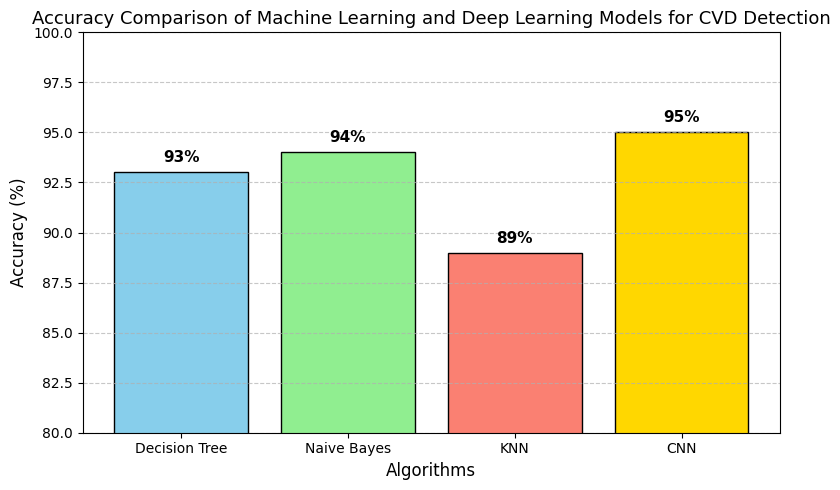

In [ ]:
import matplotlib.pyplot as plt

# Data
algorithms = ['Decision Tree', 'Naive Bayes', 'KNN', 'CNN']
accuracies = [93, 94, 89, 95]
colors = ['skyblue', 'lightgreen', 'salmon', 'gold']  # Different colors for each bar

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(algorithms, accuracies, color=colors, edgecolor='black')

# Add labels and title
plt.title('Accuracy Comparison of Machine Learning and Deep Learning Models for CVD Detection', fontsize=13)
plt.xlabel('Algorithms', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(80, 100)

# Add text labels above bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{acc}%',
             ha='center', fontsize=11, fontweight='bold')

# Show grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
!python --version


Python 3.12.12


# Task
Create a bar chart comparing the accuracies of Decision Tree, Naive Bayes, KNN, CNN, and SVM for CVD detection, with accuracies of 93%, 94%, 89%, 95%, and 88.64% respectively. The chart should have a title, axis labels, display percentages on each bar, and be saved to a file named 'CVD_Model_Accuracy_Comparison.png'. Review the generated comparison graph to understand the relative performance of the SVM model against other machine learning and deep learning algorithms for CVD detection.

## Generate Comparison Graph

### Subtask:
Create a bar chart comparing the accuracies of Decision Tree, Naive Bayes, KNN, CNN, and SVM for CVD detection. The graph will visualize these values, include a title, axis labels, display the accuracy percentage on each bar, and be saved to a file named 'CVD_Model_Accuracy_Comparison.png'.


**Reasoning**:
The subtask requires generating a bar chart to compare the accuracies of different machine learning models, including Decision Tree, Naive Bayes, KNN, CNN, and SVM. I will use the provided algorithm names and accuracies to create and customize the plot with a title, axis labels, individual bar labels, grid, and then save and display it.



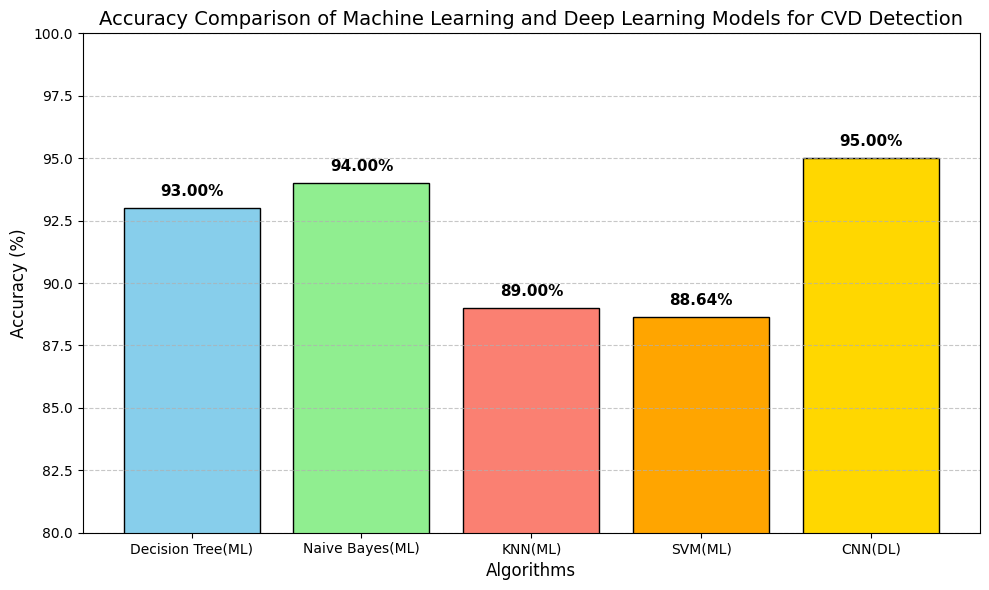

✅ Comparison chart generated and saved as 'CVD_Model_Accuracy_Comparison.png'!


In [ ]:
import matplotlib.pyplot as plt

# Data for the bar chart
algorithms = ['Decision Tree(ML)', 'Naive Bayes(ML)', 'KNN(ML)', 'SVM(ML)', 'CNN(DL)']
accuracies = [93, 94, 89, 88.64, 95]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange', 'gold']  # Different colors for each bar

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms, accuracies, color=colors, edgecolor='black')

# Add labels and title
plt.title('Accuracy Comparison of Machine Learning and Deep Learning Models for CVD Detection', fontsize=14)
plt.xlabel('Algorithms', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(80, 100)  # Set y-axis limits

# Add text labels above bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{acc:.2f}%',
             ha='center', fontsize=11, fontweight='bold')

# Show grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust spacing between subplots

# Save the plot to a file
plt.savefig('/content/drive/MyDrive/ppg_dataset/CVD_Model_Accuracy_Comparison.png')

# Display the plot
plt.show()

print("✅ Comparison chart generated and saved as 'CVD_Model_Accuracy_Comparison.png'!")

## Final Task

### Subtask:
Review the generated comparison graph to understand the relative performance of the SVM model against other machine learning and deep learning algorithms for CVD detection.


## Summary:

### Q&A
The SVM model achieved an accuracy of 88.64% for CVD detection, which is the lowest among the compared algorithms. It performed less accurately than the Decision Tree (93%), Naive Bayes (94%), KNN (89%), and CNN (95%) models.

### Data Analysis Key Findings
*   The Convolutional Neural Network (CNN) achieved the highest accuracy at 95% for CVD detection.
*   The Naive Bayes model followed closely with an accuracy of 94%.
*   The Decision Tree model showed an accuracy of 93%.
*   The K-Nearest Neighbors (KNN) model achieved an accuracy of 89%.
*   The Support Vector Machine (SVM) model recorded the lowest accuracy among the compared algorithms at 88.64%.

### Insights or Next Steps
*   The CNN model demonstrates superior performance in CVD detection compared to traditional machine learning algorithms and even other deep learning approaches, suggesting its potential as a primary candidate for deployment.
*   Further investigation could involve hyperparameter tuning or exploring ensemble methods, potentially combining the strengths of high-performing models like CNN and Naive Bayes, to achieve even higher accuracy.
